[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Neutrino155/diffusion-model-tutorial/blob/main/sota-crystals-comparison.ipynb)


# Crystal Generation SOTA Comparison: MatterGen first, Chemeleon-DNG second

This notebook is a standalone guide to two modern crystal diffusion systems. The earlier diffusion fundamentals and crystal-from-scratch notebooks are useful background, but everything needed for the walkthrough here is introduced again in a practical, usage-first way.

## Aims

- understand what MatterGen and Chemeleon-DNG diffuse and what kind of control each one exposes,
- run both unconditional and conditional generation workflows,
- inspect their outputs with the same lightweight screening tools: density, volume, atom count, galleries, and trajectories,
- leave with a clear picture of what each toolkit is best suited for.

## Learning outcomes

By the end you should be able to:

1. run a MatterGen unconditional sample and a low-vs-high property-conditioned sweep,
2. run Chemeleon-DNG in both **DNG** and **CSP** modes,
3. explain the difference between scalar-property steering, formula-conditioned generation, and post-generation screening,
4. interpret trajectory plots and output distributions as workflow diagnostics rather than formal benchmarks.

MatterGen comes first because it is the cleaner continuation of direct crystal diffusion. Chemeleon-DNG follows as a more task-oriented toolkit built around the same broad family of ideas.

## Runtime expectations

- The first full run is **network- and install-heavy** because it builds two separate environments and downloads pretrained weights.
- Expect the first end-to-end pass to be the slowest notebook in the tutorial; on a typical CPU-backed setup it can easily take **20--40+ minutes** depending on download speed and whether caches already exist.
- MatterGen setup plus the first conditioned sweep is the slower half of the notebook.
- The first Chemeleon-DNG DNG/CSP call downloads roughly **523 MB** of checkpoints.
- Repeat runs are much faster because the repos, environments, checkpoints, and generated outputs are reused.


## How to use this notebook

Treat this notebook as a three-part comparison.

1. **MatterGen:** learn the closest production-style continuation of direct crystal diffusion.
2. **Comparison lens:** pause and line up the ideas before switching toolkits.
3. **Chemeleon-DNG:** study a second diffusion system that exposes two user-facing tasks, DNG and CSP.

The comparison is organized around four questions:

- **What is the conditioning signal?**
- **What controls remain at sampling time?**
- **What kind of candidate pool do you get back?**
- **How do you screen that pool after generation?**

| Model | Best first mental model | Main conditional handle shown here | Main post-generation readout |
| --- | --- | --- | --- |
| MatterGen | checkpointed crystal diffusion with optional scalar guidance | band-gap target + guidance factor | density / volume / site-count shifts and trajectory inspection |
| Chemeleon-DNG | task-oriented crystal diffusion toolkit | formula conditioning in CSP, atom-count schedule in DNG | density / volume / formula-match checks and galleries |

A good reading strategy is: run the MatterGen half, read the comparison lens, then move to Chemeleon-DNG while keeping those four questions in mind.

## Primary sources and papers

This notebook is organized around the official upstream repositories and papers for the two systems it compares. The model setup cells pin the external model repos below:

- MatterGen repository: https://github.com/microsoft/mattergen
- MatterGen paper: https://www.nature.com/articles/s41586-025-08628-5
- MatterGen commit pinned in this notebook: `a245cf2b7538eea6d873e6430b0e30c56d26c60e`
- Chemeleon repository and paper: https://github.com/hspark1212/chemeleon and https://www.nature.com/articles/s41467-025-59636-y
- Chemeleon-DNG repository: https://github.com/hspark1212/chemeleon-dng
- Chemeleon-DNG commit pinned in this notebook: `0d8da3a82a0c2211245a1b1394b599ca0545883c`
- The Materials Project paper and API docs: https://doi.org/10.1063/1.4812323 and https://materialsproject.github.io/api/

The goal here is to understand how to run, inspect, and compare these systems in practice, rather than to reproduce their full pretraining pipelines.


## Table of Contents

- [Primary sources and papers](#primary-sources-and-papers)

### MatterGen path
1. [Install prerequisites](#1-install-prerequisites-colab-friendly)
2. [Methodology and theory](#2-methodology-and-theory-teaching-notes)
3. [MatterGen architecture map](#3-mattergen-architecture-map-code-oriented-orientation)
4. [Unconditional generation](#4-unconditional-generation-with-a-pre-trained-checkpoint)
5. [Property-conditioned generation: low and high band gap targets](#5-property-conditioned-generation-low-and-high-band-gap-targets)
6. [Parse MatterGen outputs](#6-parse-mattergen-outputs-into-python-objects)
7. [Distribution shifts, galleries, and lightweight screening](#7-distribution-shifts-galleries-and-lightweight-screening)
8. [3D visualization of a generated crystal](#8-3d-visualization-of-a-generated-crystal)
9. [MatterGen trajectory archive walkthrough](#mattergen-trajectory-archive-walkthrough)
10. [Exercises](#9-exercises)
11. [Troubleshooting](#10-troubleshooting-colab)

### Bridge and comparison
1. [MatterGen vs Chemeleon-DNG: the comparison lens](#mattergen-vs-chemeleon-dng-the-comparison-lens)
2. [Decision table](#decision-table)

### Chemeleon-DNG path
1. [Chemeleon-DNG: DNG and CSP](#chemeleon-dng-dng-and-csp)
2. [What is Chemeleon-DNG?](#what-is-chemeleon-dng)
3. [1) Setup](#1-setup)
4. [2) How it works](#2-how-it-works)
5. [3) DNG quickstart](#3-dng-quickstart-generate-crystals-from-scratch)
6. [4) DNG steering and output analysis](#4-dng-steering-and-output-analysis)
7. [5) CSP quickstart: formula-conditioned generation](#5-csp-quickstart-formula-conditioned-generation)
8. [6) CSP distributions, galleries, and screening](#6-csp-distributions-galleries-and-screening)
9. [7) Comparison lens: MatterGen vs Chemeleon-DNG](#7-comparison-lens-mattergen-vs-chemeleon-dng)
10. [8) Exercises](#8-exercises)
11. [9) Troubleshooting](#9-troubleshooting)
12. [10) Next steps](#10-next-steps)


## 1. Install prerequisites (Colab-friendly)

This section anchors the notebook to the `diffusion-model-tutorial` repo root, clones `microsoft/mattergen` locally, checks out the pinned commit `a245cf2b7538`, installs it into a repo-local Python 3.10 virtual environment, and sets up the analysis stack used later in the notebook.

The first run needs network access so the repo can be cloned and the checkpoints can be fetched when requested.


In [1]:
# @title
# Install MatterGen into a repo-local Python 3.10 environment and anchor all later paths to this notebook's repo root.
from pathlib import Path
import os
import shutil
import subprocess
import sys

!pip install ase==3.25.0

def find_notebook_root():
    cwd = Path.cwd().resolve()
    search_roots = [cwd, *cwd.parents]
    explicit_roots = [
        Path('$HOME/../content'),
    ]
    for candidate in [*search_roots, *explicit_roots]:
        if (candidate / 'sota-crystals-comparison.ipynb').exists() and (candidate / 'README.md').exists():
            return candidate.resolve()
        nested = candidate / 'diffusion-model-tutorial'
        if (nested / 'sota-crystals-comparison.ipynb').exists() and (nested / 'README.md').exists():
            return nested.resolve()
    raise FileNotFoundError('Could not locate the diffusion-model-tutorial repo root from the current working directory.')


# Clone the diffusion-model-tutorial repository if it doesn't exist
repo_name = 'diffusion-model-tutorial'
repo_path_in_content = Path('/content') / repo_name
if not repo_path_in_content.exists():
    print(f'Cloning {repo_name} into /content/...')
    subprocess.run(['git', 'clone', 'https://github.com/Neutrino155/diffusion-model-tutorial.git', str(repo_path_in_content)], check=True)
    print(f'{repo_name} cloned successfully.')
else:
    print(f'Repository {repo_name} already exists in {repo_path_in_content}. Skipping clone.')


NOTEBOOK_ROOT = find_notebook_root()
os.chdir(NOTEBOOK_ROOT)
print('Notebook root:', NOTEBOOK_ROOT)

repo_dir = NOTEBOOK_ROOT / 'mattergen_repo'
venv_dir = repo_dir / '.venv'
MATTERGEN_REMOTE = 'https://github.com/microsoft/mattergen.git'
MATTERGEN_COMMIT = 'a245cf2b7538eea6d873e6430b0e30c56d26c60e'
cache_dir = Path('/tmp/uv-cache')
python_dir = Path('/tmp/uv-python')
cache_dir.mkdir(parents=True, exist_ok=True)
python_dir.mkdir(parents=True, exist_ok=True)

env = os.environ.copy()
env['UV_CACHE_DIR'] = str(cache_dir)
env['UV_PYTHON_INSTALL_DIR'] = str(python_dir)

uv_bin = shutil.which('uv')
if uv_bin is None:
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'uv'], check=True)
    uv_bin = shutil.which('uv') or str(Path.home() / '.local/bin/uv')

if not repo_dir.exists():
    subprocess.run([
        'git',
        'clone',
        MATTERGEN_REMOTE,
        str(repo_dir),
    ], check=True)


def repo_has_commit(path: Path, commit: str) -> bool:
    return subprocess.run(
        ['git', '-C', str(path), 'cat-file', '-e', f'{commit}^{{commit}}'],
        check=False,
        capture_output=True,
    ).returncode == 0


if not repo_has_commit(repo_dir, MATTERGEN_COMMIT):
    subprocess.run([
        'git', '-C', str(repo_dir), 'fetch', '--depth', '1', 'origin', MATTERGEN_COMMIT
    ], check=True)
subprocess.run(['git', '-C', str(repo_dir), 'switch', '--detach', MATTERGEN_COMMIT], check=True)

if not venv_dir.exists():
    subprocess.run([
        uv_bin,
        'venv',
        str(venv_dir),
        '--python',
        '3.10',
    ], check=True, env=env)

print('Pinned MatterGen commit:', MATTERGEN_COMMIT)
print('Installing MatterGen into:', venv_dir.resolve())
subprocess.run([
    uv_bin,
    'pip',
    'install',
    '--python',
    str(venv_dir / 'bin' / 'python'),
    '-e',
    str(repo_dir),
], check=True, env=env)

subprocess.run([
    str(venv_dir / 'bin' / 'python'),
    '-c',
    'import mattergen; print(mattergen.__file__)',
], check=True, env=env)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 12.6 MB/s eta 0:00:00
Repository diffusion-model-tutorial already exists in /content/diffusion-model-tutorial. Skipping clone.
Notebook root: /content/diffusion-model-tutorial
Pinned MatterGen commit: a245cf2b7538eea6d873e6430b0e30c56d26c60e
Installing MatterGen into: /content/diffusion-model-tutorial/mattergen_repo/.venv


CompletedProcess(args=['/content/diffusion-model-tutorial/mattergen_repo/.venv/bin/python', '-c', 'import mattergen; print(mattergen.__file__)'], returncode=0)

In [2]:
# @title
import torch
import platform

print("Python:", platform.python_version())
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Python: 3.12.13
PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


## 2. Methodology and theory (teaching notes)

This section gives the minimum background needed to make the demos readable.

The notebook compares MatterGen and Chemeleon-DNG along four practical axes:

- **what gets conditioned,**
- **what controls remain at sampling time,**
- **what files or structures the model returns,**
- **how the generated pool is screened afterward.**

Keep three core questions in mind throughout:

- What object is being noised?
- What does the network predict during denoising?
- Where does the user intervention enter: checkpoint choice, scalar target, formula, or atom-count schedule?

### 2.1 Why generative modeling for computational chemistry?
Classical crystal discovery workflows (enumeration, substitution heuristics, random structure search, and high-throughput DFT) are powerful but expensive. We want a model that can:

- Learn structural priors from known inorganic crystals.
- Propose *novel* candidate structures with plausible chemistry.
- Be steerable toward target properties or target compositions.

### 2.2 Why diffusion models?
MatterGen and Chemeleon-DNG both use a diffusion-style recipe where generation is treated as iterative denoising from noise to a crystal representation. Conceptually:

1. **Forward process:** progressively corrupts a training crystal with noise.
2. **Reverse process:** a neural network learns to remove that noise step-by-step.
3. **Sampling:** start from noise at inference time and apply learned reverse dynamics.

Diffusion models are attractive because they are generally stable to train, scale well, and support multiple conditioning strategies.

### 2.3 Crystal-specific representation challenge
Crystals are not simple fixed-length vectors: they involve

- Atomic species (discrete)
- Atomic positions (continuous, periodic)
- Lattice geometry (continuous, constrained)

The models below combine geometric learning ideas with diffusion modeling so these components can be denoised coherently.

### 2.4 Conditioning intuition
The two systems expose different user-facing controls:

- **MatterGen:** the demo here uses a scalar band-gap target plus guidance.
- **Chemeleon-DNG CSP:** the condition is a target formula.
- **Chemeleon-DNG DNG:** there is no chemistry condition, but the atom-count schedule still changes where the search spends time.

### 2.5 How training works (high-level)
At a high level, training includes:

1. Sample a crystal structure from a training dataset.
2. Corrupt it at a random timestep.
3. Predict denoising targets for positions, lattice, and related terms.
4. Optimize a weighted diffusion loss over many timesteps.
5. For conditioned variants, include condition embeddings or task-specific control signals.

In practice, the repositories contain both base and fine-tuning workflows as scripts and configs; this notebook focuses on **usage** and **scientific interpretation** rather than reproducing full large-scale pretraining.

### 2.6 Practical takeaway

- MatterGen is the clearer match to direct crystal diffusion plus scalar-property steering.
- Chemeleon-DNG packages a similar backbone into two tasks: open-ended DNG and formula-conditioned CSP.
- In both cases, useful work begins after sampling, when you parse, visualize, rank, and filter the generated pool.

> **Quick check:** what makes crystals harder to model than ordinary fixed-length vectors?
>
><details><summary>Answer</summary>
>
>Crystals mix discrete atom types, continuous periodic coordinates, and constrained lattice geometry, so the model has to denoise several different kinds of variables coherently rather than one flat numeric vector.
>
></details>

## 3. MatterGen architecture map (code-oriented orientation)

If you want to connect the notebook to the repository, start from the user-facing entrypoint and then work inward:

1. `mattergen/scripts/generate.py` for sampling
2. `mattergen/generator.py` for the reverse-diffusion loop
3. `mattergen/property_embeddings.py` for conditioning
4. `mattergen/diffusion/` for losses and denoising blocks
5. `mattergen/scripts/finetune.py` for conditioned adaptation

### How to use this map

- If you only want generated structures, learn the command-line entrypoint first.
- If you want to change conditioning, inspect the property embedding path.
- If you want to modify sampling behavior, start in `generator.py`.

### Mini exercise

Open two files side-by-side and trace one generated sample from condition to output file.

<details><summary>Suggested answer</summary>

`mattergen/property_embeddings.py` builds the conditioning signal, `generator.py` feeds that signal into the sampling loop, and `scripts/generate.py` turns the whole path into a runnable command-line workflow.

</details>

## 4. Unconditional generation with a pre-trained checkpoint

We start with the base model (`mattergen_base`) because it shows the simplest complete user flow: choose a checkpoint, run generation, inspect the files, and plot the samples.

### What to notice

- The command writes a results directory with `.extxyz` samples and recorded trajectories.
- `--batch_size` and `--num_batches` control how much data you generate without changing the model.
- The output is not just one structure; it is a batch you can parse, compare, and visualize.
- This is the direct crystal-diffusion workflow, wrapped as a reproducible model checkpoint.

> **Quick check:** why is unconditional generation the right first MatterGen demo?
>
><details><summary>Answer</summary>
>
>It isolates the base crystal prior. Before we talk about guidance or property targets, we first want to see whether the pretrained model can generate plausible crystals at all.
>
></details>

In [3]:
from pathlib import Path
import os
import shutil
import subprocess

from ase.io import read as ase_read

try:
    NOTEBOOK_ROOT
except NameError:
    NOTEBOOK_ROOT = Path.cwd().resolve()

MATTERGEN_FORCE_RERUN = False
mattergen_bin = (NOTEBOOK_ROOT / 'mattergen_repo' / '.venv' / 'bin' / 'mattergen-generate').resolve()
if not mattergen_bin.exists():
    raise FileNotFoundError('MatterGen CLI not found. Run the install cell first.')


def run_mattergen_generation(
    output_dir,
    *,
    pretrained_name,
    batch_size,
    num_batches,
    record_trajectories=False,
    properties=None,
    guidance=None,
    force=MATTERGEN_FORCE_RERUN,
):
    output_dir = Path(output_dir)
    if not output_dir.is_absolute():
        output_dir = NOTEBOOK_ROOT / output_dir
    output_dir = output_dir.resolve()
    extxyz_path = output_dir / 'generated_crystals.extxyz'
    expected_samples = batch_size * num_batches
    if extxyz_path.exists() and not force:
        try:
            existing_samples = len(ase_read(extxyz_path, index=':'))
        except Exception:
            existing_samples = None
        if existing_samples == expected_samples:
            print(f'Reusing existing MatterGen outputs in {output_dir} ({existing_samples} samples)')
            return output_dir
        print(f'Found {existing_samples} existing samples in {output_dir}; regenerating for {expected_samples} samples.')

    if output_dir.exists():
        shutil.rmtree(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    cmd = [
        str(mattergen_bin),
        str(output_dir),
        f'--pretrained-name={pretrained_name}',
        f'--batch_size={batch_size}',
        f'--num_batches={num_batches}',
        f'--record_trajectories={record_trajectories}',
    ]
    if properties is not None:
        cmd.append(f'--properties_to_condition_on={properties}')
    if guidance is not None:
        cmd.append(f'--diffusion_guidance_factor={guidance}')

    env = os.environ.copy()
    env['MPLCONFIGDIR'] = env.get('MPLCONFIGDIR', '/tmp/matplotlib-cache')
    Path(env['MPLCONFIGDIR']).mkdir(parents=True, exist_ok=True)

    print('Running:', ' '.join(cmd))
    subprocess.run(cmd, check=True, env=env)
    return output_dir


results_dir = run_mattergen_generation(
    'results_unconditional',
    pretrained_name='mattergen_base',
    batch_size=3,
    num_batches=2,
    record_trajectories=True,
)

mattergen_run_info = {
    'unconditional': {
        'display_name': 'Unconditional base',
        'pretrained_name': 'mattergen_base',
        'target_label': 'none',
        'condition_kind': 'unconditional',
        'output_dir': results_dir,
    }
}

print('\nDone. Files in output directory:')
for p in sorted(results_dir.iterdir()):
    print(' ', p.name)


Running: /content/diffusion-model-tutorial/mattergen_repo/.venv/bin/mattergen-generate /content/diffusion-model-tutorial/results_unconditional --pretrained-name=mattergen_base --batch_size=3 --num_batches=2 --record_trajectories=True

Done. Files in output directory:
  generated_crystals.extxyz
  generated_crystals_cif.zip
  generated_trajectories.zip


## 5. Property-conditioned generation: low and high band gap targets

A single conditioned run is useful, but a *sweep* is much more informative. Here we use the same fine-tuned MatterGen checkpoint twice, once with a low band-gap target and once with a high band-gap target.

Two things matter here:

- the **conditioned target** is the band gap,
- the **downstream screening statistics** we will plot later are ordinary crystal statistics such as density, volume, and number of sites.

So the density plots below are not measuring target adherence directly. They are a cheap structural diagnostic that helps us see whether the conditional sweep is moving the generator into different regions of crystal space.

### What to notice

- We change the target value but keep the same conditioned checkpoint.
- We keep the guidance factor fixed so the main thing changing is the requested target.
- Looking at low and high targets side by side is the closest notebook-sized version of a conditioning study.
- After generation, we treat the outputs as a candidate pool and rank the lowest-density and highest-density structures for follow-up inspection.

> **Quick check:** why is it useful to compare low and high targets from the *same* conditioned checkpoint?
>
><details><summary>Answer</summary>
>
>It isolates the effect of the target value itself. If you change both the checkpoint and the target at the same time, it becomes harder to tell whether differences came from the learned conditional prior or from the requested condition.
>
></details>


In [4]:
from pathlib import Path

# These are real MatterGen conditional runs using the same fine-tuned band-gap checkpoint
# at two very different target values.
MATTERGEN_CONDITIONAL_SPECS = {
    'low_band_gap': {
        'display_name': 'Low band gap target',
        'pretrained_name': 'dft_band_gap',
        'properties': repr({'dft_band_gap': 0.2}),
        'guidance': 2.0,
        'batch_size': 2,
        'num_batches': 1,
        'target_label': 'dft_band_gap = 0.2 eV',
        'condition_kind': 'scalar target',
    },
    'high_band_gap': {
        'display_name': 'High band gap target',
        'pretrained_name': 'dft_band_gap',
        'properties': repr({'dft_band_gap': 4.0}),
        'guidance': 2.0,
        'batch_size': 2,
        'num_batches': 1,
        'target_label': 'dft_band_gap = 4.0 eV',
        'condition_kind': 'scalar target',
    },
}

for label, spec in MATTERGEN_CONDITIONAL_SPECS.items():
    out_dir = run_mattergen_generation(
        f'results_{label}',
        pretrained_name=spec['pretrained_name'],
        batch_size=spec['batch_size'],
        num_batches=spec['num_batches'],
        record_trajectories=True,
        properties=spec['properties'],
        guidance=spec['guidance'],
    )
    mattergen_run_info[label] = {
        **spec,
        'output_dir': out_dir,
    }

print('\nMatterGen run registry:')
for label, spec in mattergen_run_info.items():
    print(f"- {label}: {spec['display_name']} -> {spec['output_dir']}")


Running: /content/diffusion-model-tutorial/mattergen_repo/.venv/bin/mattergen-generate /content/diffusion-model-tutorial/results_low_band_gap --pretrained-name=dft_band_gap --batch_size=2 --num_batches=1 --record_trajectories=True --properties_to_condition_on={'dft_band_gap': 0.2} --diffusion_guidance_factor=2.0
Running: /content/diffusion-model-tutorial/mattergen_repo/.venv/bin/mattergen-generate /content/diffusion-model-tutorial/results_high_band_gap --pretrained-name=dft_band_gap --batch_size=2 --num_batches=1 --record_trajectories=True --properties_to_condition_on={'dft_band_gap': 4.0} --diffusion_guidance_factor=2.0

MatterGen run registry:
- unconditional: Unconditional base -> /content/diffusion-model-tutorial/results_unconditional
- low_band_gap: Low band gap target -> /content/diffusion-model-tutorial/results_low_band_gap
- high_band_gap: High band gap target -> /content/diffusion-model-tutorial/results_high_band_gap


## 6. Parse MatterGen outputs into Python objects

Now we gather the unconditional run and the low/high conditioned sweeps into one Python-side structure so we can compare them consistently.

### Why this step matters

- It keeps the unconditional and conditioned runs aligned under one schema.
- It lets us compute density, volume, atom-count, and composition summaries with the same code.
- It makes simple downstream screening possible: for example, finding the lowest-density or highest-density candidates across all generated samples.


In [5]:
# Keep the notebook analysis stack aligned with the real MatterGen environment.
!python -m pip install --force-reinstall numpy==1.26.4 scipy==1.13.1 ase==3.25.0 matplotlib==3.8.4 pymatgen


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 5.5 MB/s eta 0:00:00
  Using cached ase-3.25.0-py3-none-any.whl.metadata (4.2 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.5/117.5 kB 9.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 8.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 6.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 6.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 43.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.2/38.2 MB 21.3 MB/s eta 0:00:00
Using cached ase-3.

In [6]:
from collections import Counter
from pathlib import Path
from html import escape
from statistics import mean

from ase.io import read
from IPython.display import HTML, display


def load_extxyz_frames(run_dir: Path):
    extxyz_path = run_dir / 'generated_crystals.extxyz'
    if not extxyz_path.exists():
        raise FileNotFoundError(f'Could not find MatterGen outputs in {run_dir}')
    return extxyz_path, read(extxyz_path, index=':')


def mattergen_row(label, atoms, local_index):
    volume = float(atoms.get_volume())
    mass = float(atoms.get_masses().sum())
    chemical_symbols = atoms.get_chemical_symbols()
    return {
        'label': label,
        'display_name': mattergen_run_info[label]['display_name'],
        'target_label': mattergen_run_info[label]['target_label'],
        'condition_kind': mattergen_run_info[label]['condition_kind'],
        'local_index': local_index,
        'formula': atoms.get_chemical_formula(),
        'elements': '-'.join(sorted(set(chemical_symbols))),
        'n_sites': len(atoms),
        'volume': volume,
        'density': mass / max(volume, 1e-12),
    }


def render_summary_table(rows):
    headers = ['run', 'target', 'samples', 'mean_n_sites', 'mean_volume', 'mean_density', 'top_formula']
    th_style = 'border:1px solid #ddd; padding:4px 8px; text-align:left; background:#eff6ff;'
    td_style = 'border:1px solid #ddd; padding:4px 8px; text-align:left;'
    body = []
    for row in rows:
        body.append(
            '<tr>'
            + ''.join(f'<td style="{td_style}">{escape(str(row[h]))}</td>' for h in headers)
            + '</tr>'
        )
    html = f'''
    <table style="border-collapse:collapse; min-width:760px; margin:0.75rem 0 1rem 0;">
      <thead><tr>{''.join(f'<th style="{th_style}">{escape(h)}</th>' for h in headers)}</tr></thead>
      <tbody>{''.join(body)}</tbody>
    </table>
    '''
    display(HTML(html))


mattergen_atoms = {}
mattergen_rows = []
summary_rows = []

for label, info in mattergen_run_info.items():
    extxyz_path, atoms_list = load_extxyz_frames(Path(info['output_dir']))
    mattergen_atoms[label] = atoms_list
    run_rows = [mattergen_row(label, atoms, i) for i, atoms in enumerate(atoms_list)]
    mattergen_rows.extend(run_rows)

    formula_counter = Counter(row['formula'] for row in run_rows)
    summary_rows.append({
        'run': info['display_name'],
        'target': info['target_label'],
        'samples': len(run_rows),
        'mean_n_sites': f"{mean(row['n_sites'] for row in run_rows):.2f}",
        'mean_volume': f"{mean(row['volume'] for row in run_rows):.2f}",
        'mean_density': f"{mean(row['density'] for row in run_rows):.3f}",
        'top_formula': formula_counter.most_common(1)[0][0],
    })
    print(f'Loaded {len(run_rows)} structures for {info["display_name"]} from {extxyz_path}')

print('\nMatterGen run summary:')
render_summary_table(summary_rows)
print('Reminder: the conditional target here is band gap, while density and volume are downstream structural diagnostics.')


Loaded 6 structures for Unconditional base from /content/diffusion-model-tutorial/results_unconditional/generated_crystals.extxyz
Loaded 2 structures for Low band gap target from /content/diffusion-model-tutorial/results_low_band_gap/generated_crystals.extxyz
Loaded 2 structures for High band gap target from /content/diffusion-model-tutorial/results_high_band_gap/generated_crystals.extxyz

MatterGen run summary:


run,target,samples,mean_n_sites,mean_volume,mean_density,top_formula
Unconditional base,none,6,8.50,208.91,5.198,Dy6Ru2
Low band gap target,dft_band_gap = 0.2 eV,2,15.00,249.77,4.697,Co2Hf4Mo6
High band gap target,dft_band_gap = 4.0 eV,2,8.50,196.97,2.410,ClLa2O2


Reminder: the conditional target here is band gap, while density and volume are downstream structural diagnostics.


## 7. Distribution shifts, galleries, and lightweight screening

This section does two jobs.

1. It checks whether the low and high band-gap targets produce visibly different structural distributions.
2. It treats the generated structures as a small screening pool and ranks them by ordinary crystal density, just like a lightweight discovery workflow.

### What to notice

- We are *conditioning on band gap* but *screening on structure*.
- Density, volume, and atom count are not substitutes for property evaluation, but they are cheap and immediately informative.
- The highest-density and lowest-density galleries are useful because they show what the tails of the generated distribution actually look like.
- The small shortlist tables are intentionally practical: this is close to the first triage step you might do before relaxation or DFT.

> **Quick check:** why is ordinary crystal density still worth plotting even when band gap is the actual conditioning target?
>
><details><summary>Answer</summary>
>
>Because density is a cheap structural statistic that can reveal whether different targets are pushing the generator into different geometric regimes. It is a downstream screening diagnostic, not a direct measure of band-gap accuracy.
>
></details>


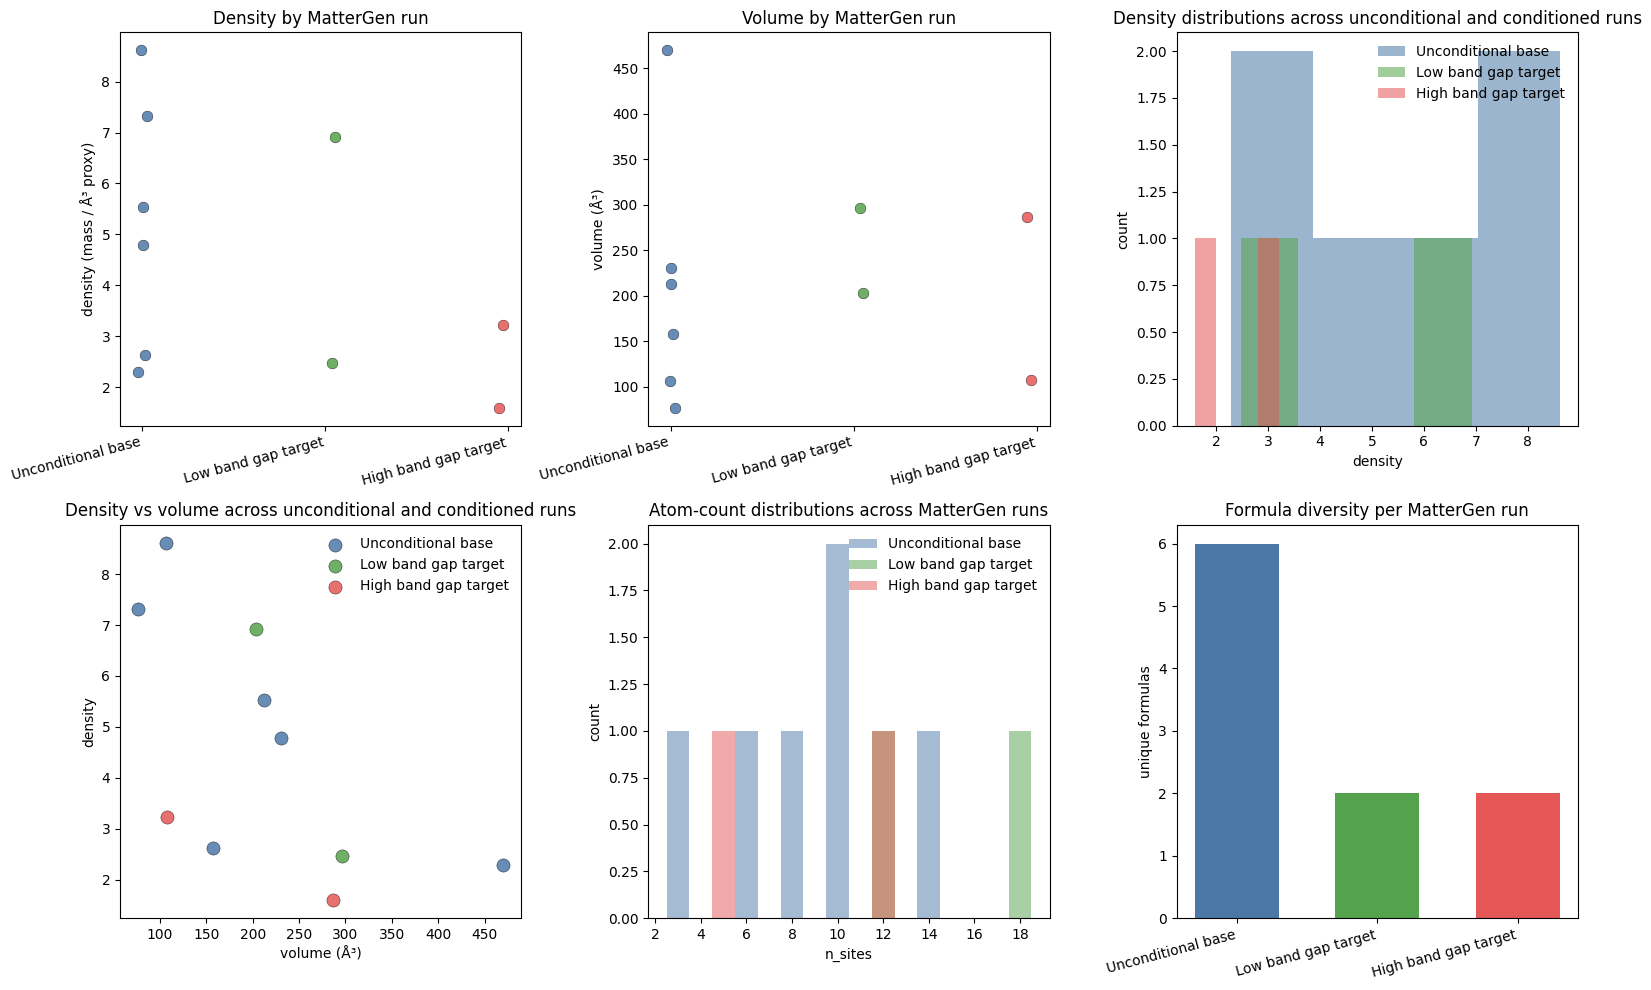

Per-run averages:
- Unconditional base: mean density=5.198, mean volume=208.91, mean n_sites=8.50
- Low band gap target: mean density=4.697, mean volume=249.77, mean n_sites=15.00
- High band gap target: mean density=2.410, mean volume=196.97, mean n_sites=8.50


display_name,target_label,formula,n_sites,volume,density
High band gap target,dft_band_gap = 4.0 eV,Cs2O8S2,12,286.817,1.597
Unconditional base,none,I6NiRb2Sr,10,469.985,2.295
Low band gap target,dft_band_gap = 0.2 eV,Cs2Cu2F12Fe2,18,296.146,2.474
Unconditional base,none,LiMg3O8Rh2,14,157.380,2.628


display_name,target_label,formula,n_sites,volume,density
Unconditional base,none,AuHg2Pd3,6,106.487,8.615
Unconditional base,none,PbPtTb,3,76.639,7.323
Low band gap target,dft_band_gap = 0.2 eV,Co2Hf4Mo6,12,203.392,6.920
Unconditional base,none,Dy6Ru2,8,212.609,5.537


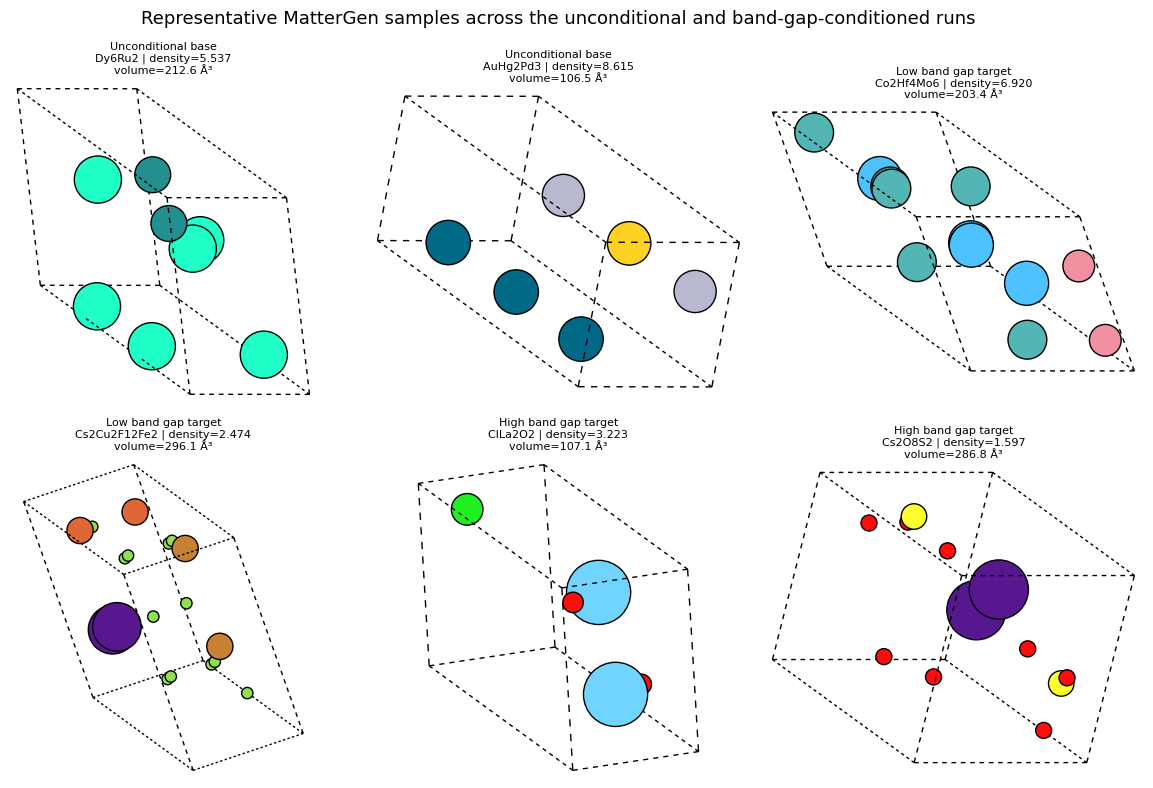

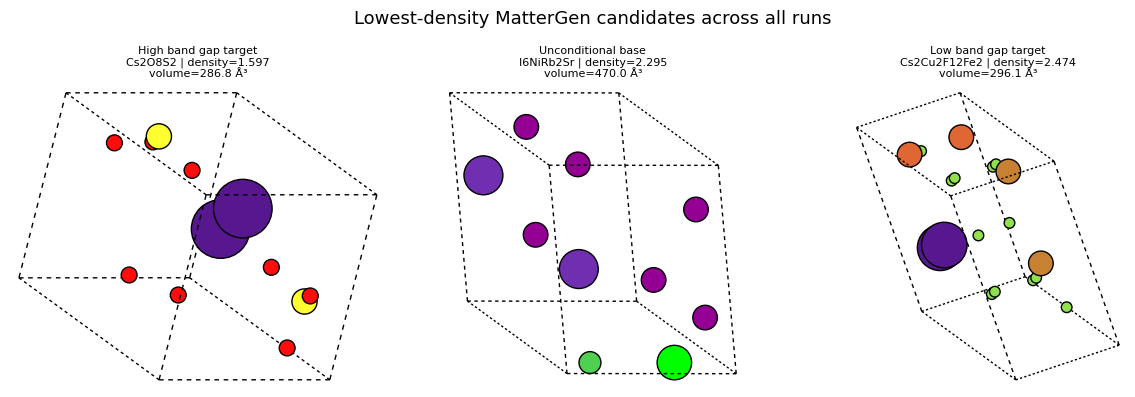

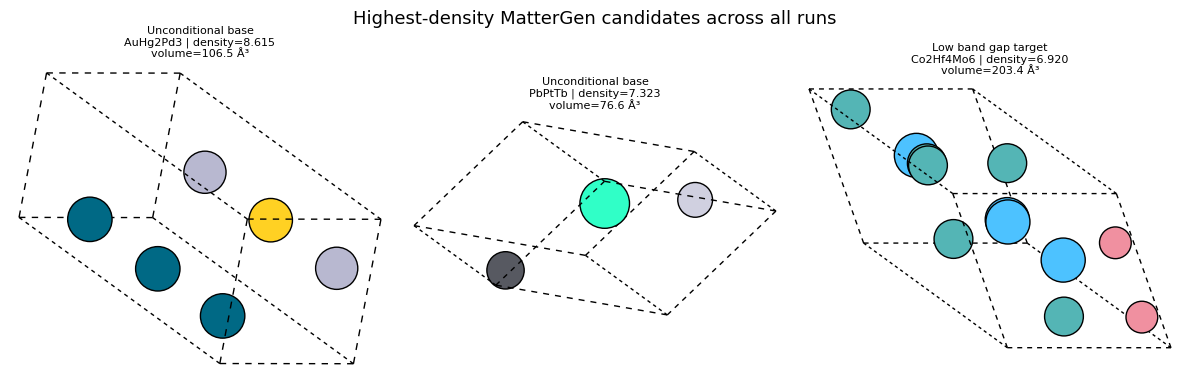

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from html import escape
from IPython.display import HTML, display
from ase.visualize.plot import plot_atoms

palette = {
    'unconditional': '#4c78a8',
    'low_band_gap': '#54a24b',
    'high_band_gap': '#e45756',
}
label_order = list(mattergen_run_info.keys())


def rows_for(label):
    return [row for row in mattergen_rows if row['label'] == label]


def render_rank_table(title, rows, headers):
    th_style = 'border:1px solid #ddd; padding:4px 8px; text-align:left; background:#eff6ff;'
    td_style = 'border:1px solid #ddd; padding:4px 8px; text-align:left;'

    def fmt(value):
        if isinstance(value, float):
            return f'{value:.3f}'
        return str(value)

    body = []
    for row in rows:
        body.append(
            '<tr>'
            + ''.join(f'<td style="{td_style}">{escape(fmt(row[h]))}</td>' for h in headers)
            + '</tr>'
        )
    html = f'''<div style="margin:0.5rem 0 0.25rem 0; font-weight:600;">{escape(title)}</div>
    <table style="border-collapse:collapse; min-width:760px; margin:0.35rem 0 1rem 0;">
      <thead><tr>{''.join(f'<th style="{th_style}">{escape(h)}</th>' for h in headers)}</tr></thead>
      <tbody>{''.join(body)}</tbody>
    </table>'''
    display(HTML(html))


fig, axes = plt.subplots(2, 3, figsize=(16, 10), facecolor='white')
rng = np.random.default_rng(0)
for x, label in enumerate(label_order, start=1):
    rows = rows_for(label)
    densities = [row['density'] for row in rows]
    volumes = [row['volume'] for row in rows]
    n_sites = [row['n_sites'] for row in rows]
    jitter = rng.normal(0.0, 0.04, size=len(rows)) if rows else np.array([])

    axes[0, 0].scatter(np.full(len(rows), x) + jitter, densities, s=60, alpha=0.85, color=palette.get(label, '#666666'), edgecolors='black', linewidths=0.3)
    axes[0, 1].scatter(np.full(len(rows), x) + jitter, volumes, s=60, alpha=0.85, color=palette.get(label, '#666666'), edgecolors='black', linewidths=0.3)
    axes[1, 2].bar(x, len({row['formula'] for row in rows}), color=palette.get(label, '#666666'), width=0.6)
    axes[1, 0].scatter(volumes, densities, s=90, alpha=0.85, label=mattergen_run_info[label]['display_name'], color=palette.get(label, '#666666'), edgecolors='black', linewidths=0.3)
    axes[0, 2].hist(densities, bins=4, alpha=0.55, color=palette.get(label, '#666666'), label=mattergen_run_info[label]['display_name'])
    axes[1, 1].hist(n_sites, bins=np.arange(min(n_sites) - 0.5, max(n_sites) + 1.5, 1.0) if n_sites else np.arange(0.5, 1.5), alpha=0.5, color=palette.get(label, '#666666'), label=mattergen_run_info[label]['display_name'])

for ax, ylabel, title in [
    (axes[0, 0], 'density (mass / Å³ proxy)', 'Density by MatterGen run'),
    (axes[0, 1], 'volume (Å³)', 'Volume by MatterGen run'),
]:
    ax.set_xticks(range(1, len(label_order) + 1))
    ax.set_xticklabels([mattergen_run_info[label]['display_name'] for label in label_order], rotation=15, ha='right')
    ax.set_ylabel(ylabel)
    ax.set_title(title)

axes[0, 2].set_title('Density distributions across unconditional and conditioned runs')
axes[0, 2].set_xlabel('density')
axes[0, 2].set_ylabel('count')
axes[0, 2].legend(frameon=False)

axes[1, 0].set_title('Density vs volume across unconditional and conditioned runs')
axes[1, 0].set_xlabel('volume (Å³)')
axes[1, 0].set_ylabel('density')
axes[1, 0].legend(frameon=False)

axes[1, 1].set_title('Atom-count distributions across MatterGen runs')
axes[1, 1].set_xlabel('n_sites')
axes[1, 1].set_ylabel('count')
axes[1, 1].legend(frameon=False)

axes[1, 2].set_xticks(range(1, len(label_order) + 1))
axes[1, 2].set_xticklabels([mattergen_run_info[label]['display_name'] for label in label_order], rotation=15, ha='right')
axes[1, 2].set_ylabel('unique formulas')
axes[1, 2].set_title('Formula diversity per MatterGen run')

plt.tight_layout()
plt.show()

print('Per-run averages:')
for label in label_order:
    rows = rows_for(label)
    print(
        f"- {mattergen_run_info[label]['display_name']}: "
        f"mean density={np.mean([row['density'] for row in rows]):.3f}, "
        f"mean volume={np.mean([row['volume'] for row in rows]):.2f}, "
        f"mean n_sites={np.mean([row['n_sites'] for row in rows]):.2f}"
    )


sorted_by_density = sorted(mattergen_rows, key=lambda row: row['density'])
render_rank_table(
    'Lowest-density MatterGen candidates across all runs',
    sorted_by_density[:4],
    ['display_name', 'target_label', 'formula', 'n_sites', 'volume', 'density'],
)
render_rank_table(
    'Highest-density MatterGen candidates across all runs',
    list(reversed(sorted_by_density[-4:])),
    ['display_name', 'target_label', 'formula', 'n_sites', 'volume', 'density'],
)


def show_mattergen_gallery(selected_rows, title, *, columns=3):
    selected_rows = list(selected_rows)
    if not selected_rows:
        print(f'No MatterGen structures available for {title}')
        return
    cols = min(columns, len(selected_rows))
    nrows = int(np.ceil(len(selected_rows) / cols))
    fig, axes = plt.subplots(nrows, cols, figsize=(4 * cols, 4 * nrows), squeeze=False, facecolor='white')
    for ax in axes.ravel():
        ax.axis('off')
    for ax, row in zip(axes.ravel(), selected_rows):
        atoms = mattergen_atoms[row['label']][row['local_index']]
        plot_atoms(atoms, ax=ax, rotation='20x,30y,0z', radii=0.35, show_unit_cell=2)
        ax.set_title(
            f"{row['display_name']}\n{row['formula']} | density={row['density']:.3f}\nvolume={row['volume']:.1f} Å³",
            fontsize=8,
        )
        ax.set_axis_off()
    fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()


representative_rows = []
for label in label_order:
    representative_rows.extend(rows_for(label)[:2])
show_mattergen_gallery(
    representative_rows,
    'Representative MatterGen samples across the unconditional and band-gap-conditioned runs',
    columns=3,
)
show_mattergen_gallery(
    sorted_by_density[:3],
    'Lowest-density MatterGen candidates across all runs',
    columns=3,
)
show_mattergen_gallery(
    list(reversed(sorted_by_density[-3:])),
    'Highest-density MatterGen candidates across all runs',
    columns=3,
)


## 8. 3D visualization of a generated crystal

Before looking at a full diffusion path, it helps to inspect one finished sample by itself.

### What to notice

- A single final sample lets you ask the simplest question first: does the decoded crystal look plausible?
- Looking at two viewing angles helps separate lattice shape from atomic arrangement.
- This is a structure-level check; the trajectory section below is a process-level check.

Showing unconditional sample 0 from /content/diffusion-model-tutorial/results_unconditional/generated_crystals.extxyz
Formula: Dy6Ru2
Number of atoms: 8
Volume: 212.61 Å³


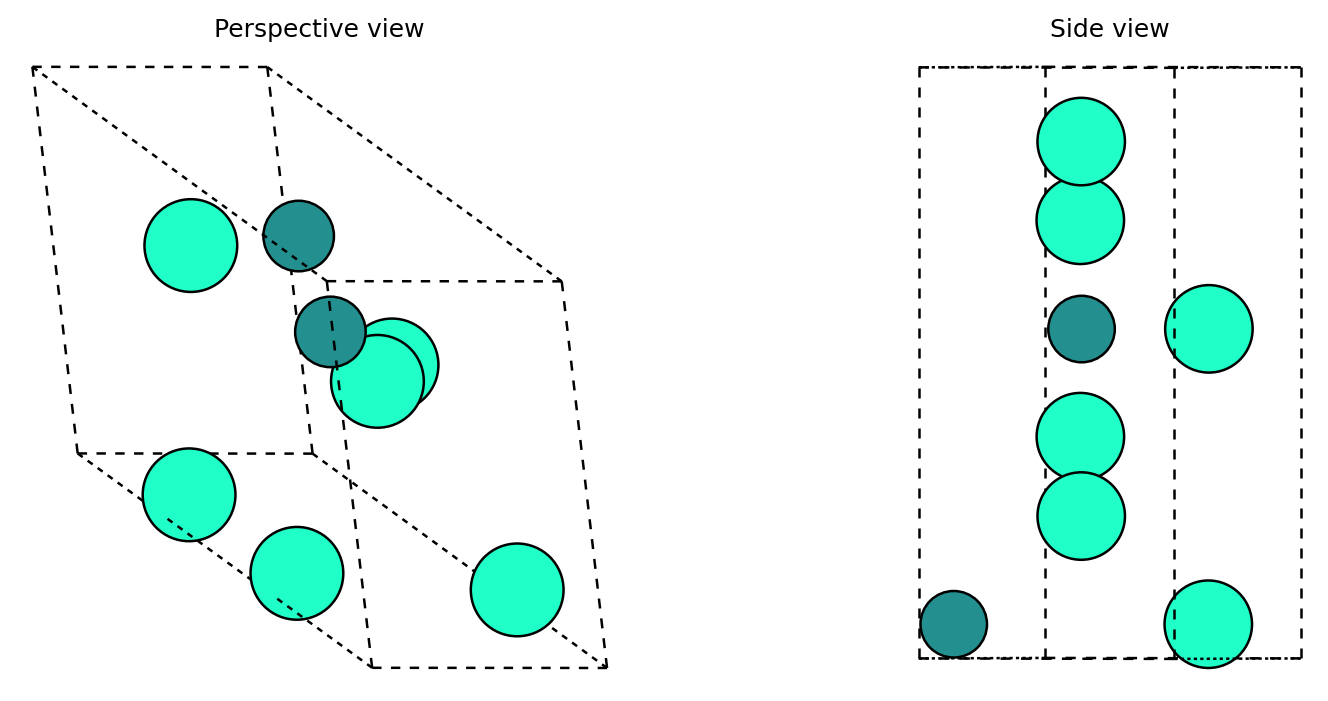

In [8]:
import matplotlib.pyplot as plt
from ase.io import read
from ase.visualize.plot import plot_atoms
from IPython.display import Image, display

preview_dir = (NOTEBOOK_ROOT / 'mattergen_figures').resolve()
preview_dir.mkdir(parents=True, exist_ok=True)

unconditional_extxyz = mattergen_run_info['unconditional']['output_dir'] / 'generated_crystals.extxyz'
if not unconditional_extxyz.exists():
    raise FileNotFoundError(f'Could not find {unconditional_extxyz}. Run the unconditional MatterGen cell first.')

unconditional_atoms = read(unconditional_extxyz, index=':')
selected_sample_index = 0
selected_atoms = unconditional_atoms[selected_sample_index]
preview_path = preview_dir / 'mattergen_unconditional_sample.png'

print(f'Showing unconditional sample {selected_sample_index} from {unconditional_extxyz}')
print('Formula:', selected_atoms.get_chemical_formula())
print('Number of atoms:', len(selected_atoms))
print(f'Volume: {selected_atoms.get_volume():.2f} Å³')

fig, axes = plt.subplots(1, 2, figsize=(10, 4), squeeze=False, facecolor='white')
for ax, rotation, title in zip(
    axes[0],
    ['20x,30y,0z', '90x,0y,0z'],
    ['Perspective view', 'Side view'],
):
    plot_atoms(selected_atoms, ax, rotation=rotation, radii=0.35, show_unit_cell=2)
    ax.set_title(title, fontsize=10)
    ax.set_axis_off()
plt.tight_layout()
fig.savefig(preview_path, dpi=180, bbox_inches='tight', facecolor='white')
plt.close(fig)

display(Image(filename=str(preview_path)))


> **Quick check:** why is it useful to inspect a final sample separately from a diffusion trajectory?
>
><details><summary>Answer</summary>
>
>They answer different questions. A final-sample plot asks whether the decoded crystal itself looks plausible, while a trajectory plot asks how the model moved from noise toward that sample and whether the denoising path looks smooth or erratic.
>
></details>

## 9. Exercises

1. **Low vs high targets:** Why is a low-vs-high target sweep more informative than a single conditioned run?

<details><summary>Suggested answer</summary>

A sweep shows directionality. You are no longer asking only whether conditioning changes the samples, but whether changing the target moves the outputs in a consistent way.

</details>

2. **Guidance sweep:** Repeat the band-gap runs with guidance factors `[0.0, 1.0, 2.0, 4.0]` and compare diversity versus how far the structural statistics move.

<details><summary>Suggested answer</summary>

Higher guidance should usually make the conditional signal stronger, but the samples may become less diverse or less realistic if the guidance is too aggressive.

</details>

3. **Screening logic:** Why is it sensible to rank generated structures by density or volume before running a more expensive relaxation or DFT workflow?

<details><summary>Suggested answer</summary>

Those statistics are cheap to compute and can quickly separate obviously sparse, crowded, or unusual structures before you spend time on more expensive downstream analysis.

</details>

4. **Property vs structure:** Which part of this MatterGen demo reflects the *conditioning signal*, and which part reflects the *screening workflow*?

<details><summary>Suggested answer</summary>

The band-gap target and guidance are the conditioning signal. The density, volume, and gallery ranking steps are the screening workflow applied after generation.

</details>


## 10. Troubleshooting (Colab)

- **Out of memory:** reduce `--batch_size`.
- **Slow runtime:** ensure GPU runtime is selected. MatterGen's reverse process is long enough that conditioned sweeps can feel slow on CPU.
- **Package conflicts:** restart runtime and rerun setup cells.
- **MatterGen install problems:** confirm network access, the `mattergen_repo` clone, and rerun the repo-local venv install cell.
- **Checkpoint download delays:** the first call to a new pretrained checkpoint may take time while files are fetched from Hugging Face.
- **Analysis cells look stale:** rerun the MatterGen parsing and visualization cells after generating fresh outputs.
- **You want a fresh run:** set `MATTERGEN_FORCE_RERUN = True` in the generation cell before rerunning the notebook.


## MatterGen trajectory archive walkthrough

MatterGen can also record the reverse-diffusion path, not just the final crystals. In this section we unpack that archive, select **one** trajectory file, and follow that single candidate from noisy start to final structure.

## Unpack the recorded trajectory archive and choose one path

Extracted 6 trajectory files from generated_trajectories.zip
Selected one trajectory: gen_0.extxyz
Loaded 2000 frames from that single reverse-diffusion path
First-frame formula: Md8
Last-frame formula: Dy6Ru2


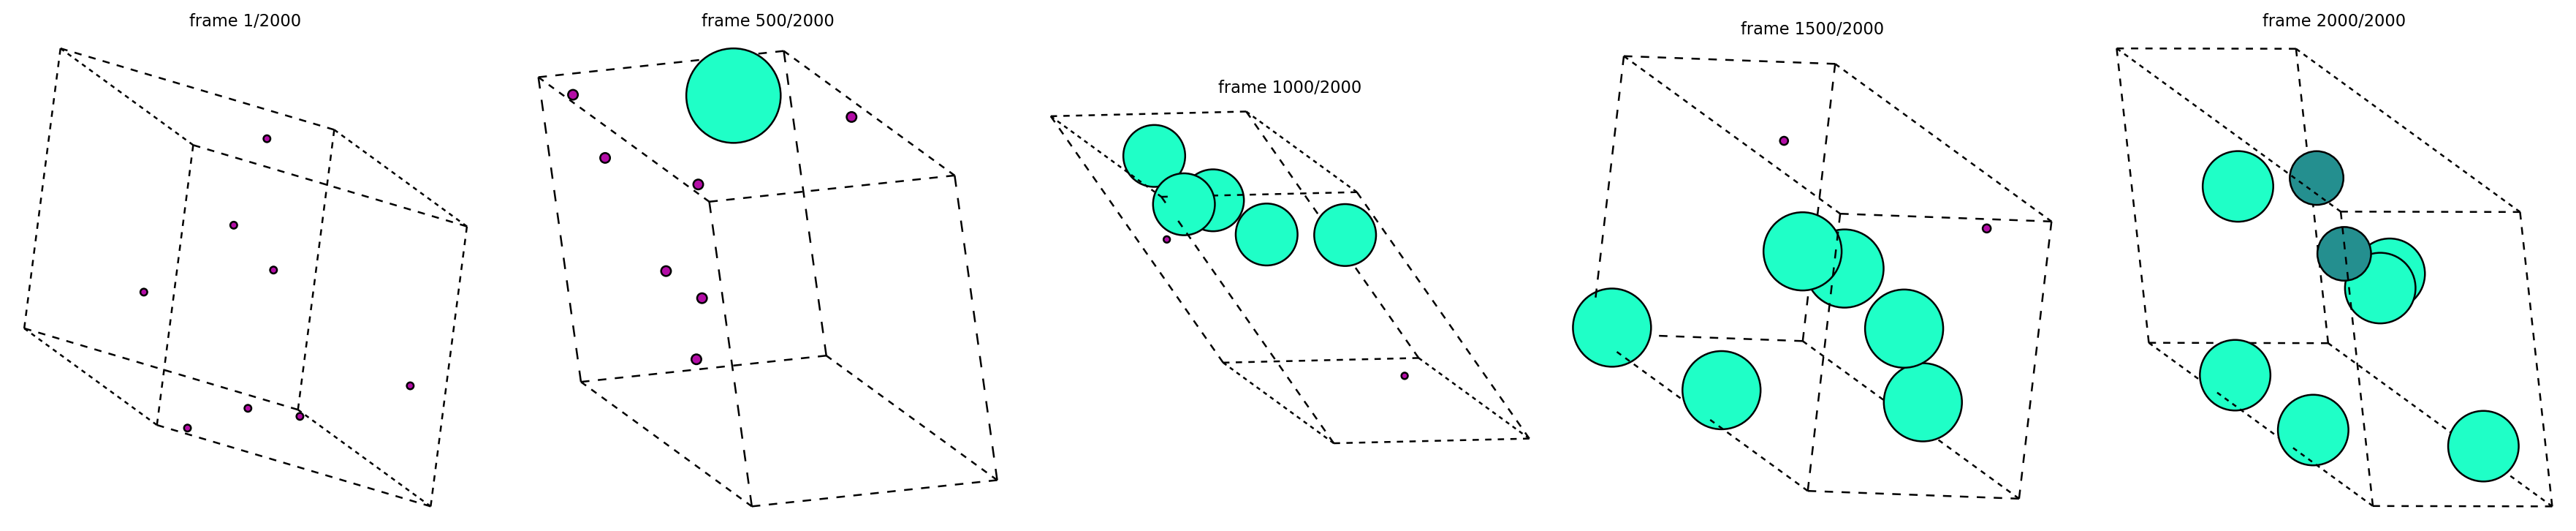

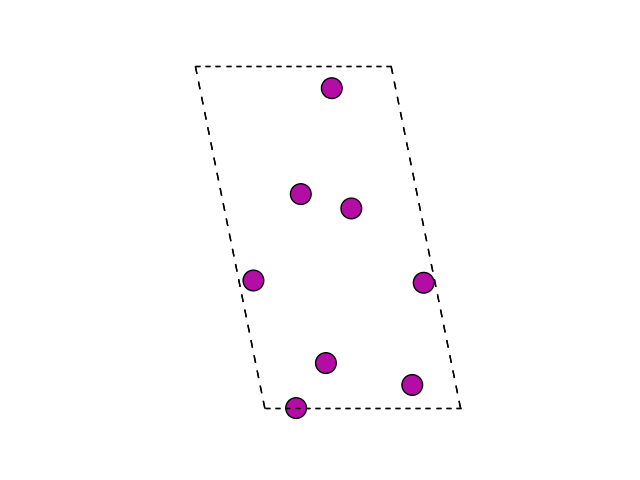

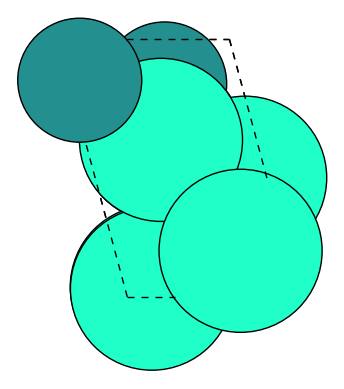

In [9]:
from pathlib import Path
import shutil
import zipfile

import matplotlib.pyplot as plt
import numpy as np
from ase.io import read, write
from ase.visualize.plot import plot_atoms
from IPython.display import Image, display

trajectory_dir = (NOTEBOOK_ROOT / 'unzipped_trajectories').resolve()
if trajectory_dir.exists():
    shutil.rmtree(trajectory_dir)
trajectory_dir.mkdir(parents=True, exist_ok=True)

zip_candidates = [
    mattergen_run_info['unconditional']['output_dir'] / 'generated_trajectories.zip',
    NOTEBOOK_ROOT / 'results_unconditional' / 'generated_trajectories.zip',
]
zip_file_path = next((p for p in zip_candidates if p.exists()), None)
if zip_file_path is None:
    raise FileNotFoundError(
        'Could not find a MatterGen trajectory archive. Run the unconditional generation cell with record_trajectories=True.'
    )

with zipfile.ZipFile(zip_file_path) as zf:
    zf.extractall(trajectory_dir)

trajectory_files = sorted(trajectory_dir.glob('gen_*.extxyz'))
if not trajectory_files:
    trajectory_files = sorted(trajectory_dir.glob('*.extxyz'))
if not trajectory_files:
    raise FileNotFoundError(f'Archive {zip_file_path} did not contain any .extxyz trajectory files.')

selected_trajectory = trajectory_files[0]
trajectory_frames = read(selected_trajectory, index=':')
if len(trajectory_frames) < 2:
    raise ValueError(f'Trajectory file {selected_trajectory.name} did not contain multiple frames.')

frame_ids = np.unique(np.linspace(0, len(trajectory_frames) - 1, num=min(5, len(trajectory_frames)), dtype=int))
preview_path = trajectory_dir / f'{selected_trajectory.stem}_preview.png'
gif_path = trajectory_dir / f'{selected_trajectory.stem}.gif'

fig, axes = plt.subplots(1, len(frame_ids), figsize=(4 * len(frame_ids), 4), squeeze=False, facecolor='white')
for ax, frame_idx in zip(axes[0], frame_ids):
    plot_atoms(trajectory_frames[frame_idx], ax, rotation='20x,30y,0z', radii=0.35, show_unit_cell=2)
    ax.set_title(f'frame {frame_idx + 1}/{len(trajectory_frames)}', fontsize=9)
    ax.set_axis_off()
plt.tight_layout()
fig.savefig(preview_path, dpi=180, bbox_inches='tight', facecolor='white')
plt.close(fig)

write(str(gif_path), trajectory_frames[::max(1, len(trajectory_frames) // 80)])

print(f'Extracted {len(trajectory_files)} trajectory files from {zip_file_path.name}')
print(f'Selected one trajectory: {selected_trajectory.name}')
print(f'Loaded {len(trajectory_frames)} frames from that single reverse-diffusion path')
print('First-frame formula:', trajectory_frames[0].get_chemical_formula())
print('Last-frame formula:', trajectory_frames[-1].get_chemical_formula())

display(Image(filename=str(preview_path)))
display(Image(filename=str(gif_path)))


### What to notice

- Every panel above comes from the same extracted trajectory file.
- Early frames should look much noisier or less chemically stable than the late frames.
- The exact intermediate chemistry can fluctuate during denoising; that is fine. The main question is whether one candidate path becomes progressively more structured.


## Summary

MatterGen gives us two complementary views of crystal diffusion:

- an unconditional crystal prior,
- a low-vs-high conditioned sweep,
- and one explicit reverse-diffusion path for a single candidate crystal.

Chemeleon-DNG will keep the same broad family of ideas but reorganize the user-facing workflow around two tasks: DNG for open-ended discovery and CSP for formula-conditioned generation.

## Transition: from MatterGen to Chemeleon-DNG

We now have a comparison frame in place:

- MatterGen emphasizes scalar-property steering on top of direct crystal diffusion.
- Chemeleon-DNG emphasizes task choice: open-ended DNG or formula-conditioned CSP.

Next we switch to the Chemeleon-DNG repo, reuse cached checkpoints if they already exist, and run both task modes in a notebook-friendly way.

In [10]:
import os

os.chdir(NOTEBOOK_ROOT)
print('Using notebook root:', os.getcwd())


Using notebook root: /content/diffusion-model-tutorial


## Chemeleon-DNG: DNG and CSP

This half is a standalone guide to the `chemeleon-dng` repository.

The idea is simple:

- **DNG**: generate crystals from scratch.
- **CSP**: generate crystal structures conditioned on a formula.

The diffusion backbone is shared. What changes is the user-facing task and therefore the kind of control you apply during sampling.

### What is Chemeleon-DNG?

Chemeleon-DNG is a task-oriented crystal diffusion toolkit.

It keeps a crystal diffusion backbone, but exposes two clean entry points:

- **DNG** for de novo generation,
- **CSP** for crystal structure prediction from a target formula.

In this notebook, the aim is not to reproduce the full training pipeline. The aim is to understand how the two task modes behave in practice and how their outputs compare with the MatterGen workflows above.

We will do four things:

1. sample a small DNG batch,
2. steer DNG with different atom-count schedules,
3. sample CSP batches for specific formulas,
4. compare the returned pools with the same lightweight screening logic used for MatterGen.

> **Quick check:** which part of Chemeleon-DNG is truly conditional generation?
>
><details><summary>Answer</summary>
>
>CSP is the explicitly conditional mode because it asks for structures compatible with a target formula. DNG is open-ended generation, although its atom-count schedule still steers the search distribution.
>
></details>

### Notebook outline

| Section | What it does |
| --- | --- |
| Setup | clones and installs `chemeleon-dng` into a clean temporary Python environment |
| How it works | explains the shared diffusion backbone and the DNG/CSP split |
| DNG quickstart | generates crystals from scratch and triggers checkpoint download on first run |
| DNG output analysis | summarizes the sampled crystal shapes and sizes |
| CSP quickstart | generates structures for specific formulas |
| CSP output analysis | compares the formula-conditioned outputs |
| Comparison lens | contrasts MatterGen with Chemeleon-DNG |
| Exercises | checks your understanding with hidden answers |

## 1) Setup

This section installs a clean `chemeleon-dng` environment and leaves the checkpoint download to the first real sampling call.

A small but important implementation detail: the notebook creates the Python environment in the system temporary directory rather than inside the repo. That avoids incomplete `torch` and `numpy` installs on mounted drives such as OneDrive, WSL bind mounts, and some Colab-backed filesystems.

What this setup cell does:

- validates or reclones the `chemeleon-dng` repository,
- checks out the pinned commit `0d8da3a82a0c`,
- creates a clean Python 3.11 environment in a temporary directory,
- installs `chemeleon-dng` into that environment,
- verifies that `chemeleon_dng`, `numpy`, and `torch` all import cleanly,
- defines the helper functions used by the DNG and CSP demos below.

The first DNG or CSP sample will automatically download about $523\,\mathrm{{MB}}$ of pretrained checkpoints into `chemeleon_dng_repo/ckpts/`. Later runs reuse those files.


In [11]:
import json
import os
import shutil
import subprocess
import sys
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from ase.visualize.plot import plot_atoms

print('Python:', sys.version)
print('Working dir:', os.getcwd())

cwd = Path.cwd().resolve()
candidate_roots = [
    cwd,
    cwd / 'diffusion-model-tutorial',
    Path('/home/uccabaa/OneDrive/Repositories/diffusion-model-tutorial'),
    Path('/mnt/c/Users/keith/OneDrive - University College London/Repositories/diffusion-model-tutorial'),
]
notebook_root = next((root for root in candidate_roots if (root / 'sota-crystals-comparison.ipynb').exists()), cwd)

CHEMELEON_DNG_REPO = (notebook_root / 'chemeleon_dng_repo').resolve()
CHEMELEON_DNG_REMOTE = 'https://github.com/hspark1212/chemeleon-dng.git'
CHEMELEON_DNG_COMMIT = '0d8da3a82a0c2211245a1b1394b599ca0545883c'
CHEMELEON_DNG_BACKUP = (notebook_root / 'chemeleon_dng_repo_incomplete_backup').resolve()
CHEMELEON_DNG_OUT = (notebook_root / 'results_chemeleon_dng').resolve()
CHEMELEON_DNG_OUT.mkdir(parents=True, exist_ok=True)
TMP_ROOT = Path(tempfile.gettempdir()).resolve()
CHEMELEON_DNG_VENV = TMP_ROOT / 'chemeleon-dng-venv'
CHEMELEON_DNG_PYTHON = CHEMELEON_DNG_VENV / 'bin' / 'python'
CHEMELEON_DNG_CLI = CHEMELEON_DNG_VENV / 'bin' / 'chemeleon-dng'
CHEMELEON_DNG_DEVICE = 'cuda'  # change to 'cuda' later if you want faster sampling on a GPU machine
CHEMELEON_DNG_DEMO_TIMESTEPS = 32  # shorter reverse process for notebook-speed demos
uv_cache_dir = TMP_ROOT / 'uv-cache-chemeleon-dng'
uv_cache_dir.mkdir(parents=True, exist_ok=True)
matplotlib_cache_dir = TMP_ROOT / 'matplotlib-cache-chemeleon-dng'
matplotlib_cache_dir.mkdir(parents=True, exist_ok=True)
base_env = os.environ.copy()
base_env['UV_CACHE_DIR'] = str(uv_cache_dir)
base_env['UV_LINK_MODE'] = 'copy'
base_env['PYTHONNOUSERSITE'] = '1'
base_env['MPLBACKEND'] = 'Agg'
base_env['MPLCONFIGDIR'] = str(matplotlib_cache_dir)


def repo_is_valid(path: Path) -> bool:
    return (path / 'pyproject.toml').exists() and (path / '.git').exists()

def repo_has_commit(path: Path, commit: str) -> bool:
    return subprocess.run(
        ['git', '-C', str(path), 'cat-file', '-e', f'{commit}^{{commit}}'],
        check=False,
        capture_output=True,
    ).returncode == 0


uv_bin = shutil.which('uv')
if uv_bin is None:
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'uv'], check=True)
    uv_bin = shutil.which('uv')
if uv_bin is None:
    raise RuntimeError('Could not find uv after installation.')

if CHEMELEON_DNG_REPO.exists() and not repo_is_valid(CHEMELEON_DNG_REPO):
    if CHEMELEON_DNG_BACKUP.exists():
        shutil.rmtree(CHEMELEON_DNG_BACKUP)
    CHEMELEON_DNG_REPO.rename(CHEMELEON_DNG_BACKUP)
    print('Moved incomplete Chemeleon-DNG directory to:', CHEMELEON_DNG_BACKUP)
if not repo_is_valid(CHEMELEON_DNG_REPO):
    subprocess.run([
        'git',
        'clone',
        CHEMELEON_DNG_REMOTE,
        str(CHEMELEON_DNG_REPO),
    ], check=True)
else:
    print('Using existing Chemeleon-DNG clone:', CHEMELEON_DNG_REPO)

if not repo_has_commit(CHEMELEON_DNG_REPO, CHEMELEON_DNG_COMMIT):
    subprocess.run([
        'git', '-C', str(CHEMELEON_DNG_REPO), 'fetch', '--depth', '1', 'origin', CHEMELEON_DNG_COMMIT
    ], check=True)
subprocess.run(['git', '-C', str(CHEMELEON_DNG_REPO), 'switch', '--detach', CHEMELEON_DNG_COMMIT], check=True)


def import_check() -> bool:
    if not CHEMELEON_DNG_PYTHON.exists():
        return False
    result = subprocess.run(
        [
            str(CHEMELEON_DNG_PYTHON),
            '-c',
            'import chemeleon_dng, numpy, torch; print(chemeleon_dng.__file__); print(numpy.__version__); print(torch.__version__)',
        ],
        cwd=str(CHEMELEON_DNG_REPO),
        env=base_env,
        capture_output=True,
        text=True,
    )
    if result.returncode == 0:
        print(result.stdout.strip())
        return True
    if result.stdout:
        print(result.stdout)
    if result.stderr:
        print(result.stderr)
    return False


if not import_check():
    if CHEMELEON_DNG_VENV.exists():
        shutil.rmtree(CHEMELEON_DNG_VENV)
    subprocess.run([uv_bin, 'venv', str(CHEMELEON_DNG_VENV), '--python', '3.11'], check=True, env=base_env)
    subprocess.run([
        uv_bin,
        'pip',
        'install',
        '--python',
        str(CHEMELEON_DNG_PYTHON),
        '-e',
        str(CHEMELEON_DNG_REPO),
    ], check=True, env=base_env)
    if not import_check():
        raise RuntimeError('Chemeleon-DNG environment was created but the import check still failed.')

commit = subprocess.check_output(
    ['git', '-C', str(CHEMELEON_DNG_REPO), 'rev-parse', '--short', 'HEAD'],
    text=True,
).strip()
print('Chemeleon-DNG repo:', CHEMELEON_DNG_REPO)
print('Chemeleon-DNG commit:', commit)
print('Pinned Chemeleon-DNG commit:', CHEMELEON_DNG_COMMIT)
print('Chemeleon-DNG venv:', CHEMELEON_DNG_VENV)
print('Chemeleon-DNG Python:', CHEMELEON_DNG_PYTHON)
print('Chemeleon-DNG CLI:', CHEMELEON_DNG_CLI)
print('Default notebook device:', CHEMELEON_DNG_DEVICE)
print('Notebook demo timesteps:', CHEMELEON_DNG_DEMO_TIMESTEPS)


def run_chemeleon_dng_python(code: str, *, device: str = CHEMELEON_DNG_DEVICE):
    run_env = base_env.copy()
    run_env['MPLBACKEND'] = 'Agg'
    run_env['MPLCONFIGDIR'] = str(matplotlib_cache_dir)
    if device == 'cpu':
        run_env['CUDA_VISIBLE_DEVICES'] = ''
    subprocess.run(
        [str(CHEMELEON_DNG_PYTHON), '-c', code],
        cwd=str(CHEMELEON_DNG_REPO),
        env=run_env,
        check=True,
    )


def sample_chemeleon_dng(
    *,
    task: str,
    output_dir: Path,
    device: str = CHEMELEON_DNG_DEVICE,
    num_samples: int = 2,
    batch_size: int | None = None,
    formulas: list[str] | None = None,
    num_atom_distribution: str | list[int] | None = 'mp-20',
    reuse_existing: bool = True,
    demo_num_timesteps: int = CHEMELEON_DNG_DEMO_TIMESTEPS,
    model_path: str | None = None,
):
    output_dir = Path(output_dir).resolve()
    output_dir.mkdir(parents=True, exist_ok=True)
    expected_count = num_samples if task == 'dng' else num_samples * len(formulas or [])
    existing = sorted(output_dir.glob('sample_*.cif'))
    if reuse_existing and expected_count and len(existing) >= expected_count:
        print(f'Reusing {len(existing)} existing CIF files from {output_dir}')
        return existing[:expected_count]

    for old in output_dir.glob('sample_*.cif'):
        old.unlink()
    json_path = output_dir / 'generated_structures.json.gz'
    if json_path.exists():
        json_path.unlink()

    code_lines = [
        'from pathlib import Path',
        'from chemeleon_dng.diffusion.diffusion_module import DiffusionModule',
        'from chemeleon_dng.sample import DEFAULT_MODEL_PATH, get_checkpoint_path, sample_csp, sample_dng',
        f'task = {json.dumps(task)}',
        f'device = {json.dumps(device)}',
        f'output_dir = Path({json.dumps(str(output_dir))})',
        'output_dir.mkdir(parents=True, exist_ok=True)',
        f'demo_num_timesteps = {int(demo_num_timesteps)}',
        f'batch_size = {int(batch_size if batch_size is not None else num_samples)}',
        f'num_samples = {int(num_samples)}',
        f'model_path = {repr(model_path)}',
        'if model_path is None:',
        '    model_path = get_checkpoint_path(task, DEFAULT_MODEL_PATH)',
        'print(f"Using checkpoint path: {model_path}")',
        'dm = DiffusionModule.load_from_checkpoint(model_path, map_location=device, weights_only=False)',
        'print(f"Original timesteps: {dm.num_timesteps}")',
        'dm.num_timesteps = demo_num_timesteps',
        'print(f"Notebook demo timesteps: {dm.num_timesteps}")',
    ]
    if formulas is not None:
        code_lines.append(f'formulas = {json.dumps(list(formulas))}')
    if num_atom_distribution is not None:
        code_lines.append(f'num_atom_distribution = {json.dumps(num_atom_distribution)}')
    code_lines.extend([
        'if task == "dng":',
        '    sample_dng(dm=dm, num_atom_distribution=num_atom_distribution, num_samples=num_samples, batch_size=batch_size, output_path=output_dir)',
        'elif task == "csp":',
        '    sample_csp(dm=dm, formulas=formulas, num_samples=num_samples, batch_size=batch_size, output_path=output_dir)',
        'else:',
        '    raise ValueError(f"Unsupported task: {task}")',
        'print("Generated CIF files:", len(list(output_dir.glob("sample_*.cif"))))',
    ])
    run_chemeleon_dng_python('\n'.join(code_lines), device=device)
    cif_paths = sorted(output_dir.glob('sample_*.cif'))
    if not cif_paths:
        raise FileNotFoundError(f'Chemeleon-DNG sampling finished but wrote no CIF files in {output_dir}')
    return cif_paths


def show_atoms_gallery(atoms_list, title: str, save_path: Path, *, columns: int = 4, subtitles=None):
    atoms_list = list(atoms_list)
    subtitles = list(subtitles) if subtitles is not None else None
    if not atoms_list:
        print(f'No structures to display for {title}')
        return None
    cols = min(columns, len(atoms_list))
    rows = int(np.ceil(len(atoms_list) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows), squeeze=False, facecolor='white')
    for ax in axes.ravel():
        ax.axis('off')
    for idx, (ax, atoms) in enumerate(zip(axes.ravel(), atoms_list)):
        plot_atoms(atoms, ax=ax, radii=0.35, rotation=('10x,15y,0z'))
        ax.set_axis_off()
        subtitle = subtitles[idx] if subtitles and idx < len(subtitles) else f'{atoms.get_chemical_formula()} | {len(atoms)} atoms'
        ax.set_title(subtitle, fontsize=9)
    fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    save_path = Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(save_path, dpi=160, bbox_inches='tight')
    plt.show()
    return fig

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Working dir: /content/diffusion-model-tutorial
/content/diffusion-model-tutorial/chemeleon_dng_repo/chemeleon_dng/__init__.py
2.4.4
2.11.0+cu130
Chemeleon-DNG repo: /content/diffusion-model-tutorial/chemeleon_dng_repo
Chemeleon-DNG commit: 0d8da3a
Pinned Chemeleon-DNG commit: 0d8da3a82a0c2211245a1b1394b599ca0545883c
Chemeleon-DNG venv: /tmp/chemeleon-dng-venv
Chemeleon-DNG Python: /tmp/chemeleon-dng-venv/bin/python
Chemeleon-DNG CLI: /tmp/chemeleon-dng-venv/bin/chemeleon-dng
Default notebook device: cpu
Notebook demo timesteps: 32


## 2) How it works

Chemeleon-DNG exposes one diffusion backbone through two user-facing tasks: DNG and CSP.

### Shared backbone
At the model level, both tasks follow the same core recipe:

1. represent a crystal by atom identities, fractional coordinates, and lattice information,
2. corrupt that representation step by step,
3. train a denoiser to reverse the corruption,
4. sample by iteratively denoising from a simple starting distribution.

### Where the control enters

- **DNG:** no target formula is provided. The main control shown here is the atom-count distribution, which biases the search toward smaller or larger cells.
- **CSP:** the target formula is fixed before sampling. The model then searches for plausible structures consistent with that chemistry.

### Comparison with MatterGen

- MatterGen keeps the same raw-crystal viewpoint but adds scalar-property steering.
- Chemeleon-DNG keeps the diffusion backbone but reorganizes the workflow around task choice.
- That means the user asks a different first question:
  - **MatterGen:** what scalar target do I want?
  - **Chemeleon-DNG:** do I want open-ended discovery or fixed-formula search?

> **Quick check:** what is shared between DNG and CSP, and what changes?
>
><details><summary>Answer</summary>
>
>They share the same broad diffusion backbone for denoising crystal representations. What changes is the conditioning interface: DNG is open-ended and uses schedule steering, while CSP conditions on a target formula.
>
></details>

## 3) DNG quickstart: generate crystals from scratch

We start Chemeleon-DNG with the purest task: de novo generation.

This first call still plays two roles:

- it checks that the repo-local Chemeleon-DNG environment is working,
- and it gives us a baseline DNG batch before we start steering the atom-count schedule in the next section.

### What to notice

- DNG does not need a target formula.
- The first call may still download checkpoints if `ckpts/` is empty.
- The notebook uses a reduced demo-length reverse process so this quickstart stays practical on CPU.
- After the quickstart batch, we can ask a more interesting question: how much can we move the output distribution by changing the atom-count schedule?


Generated: 8 structures
0 H19B 20 30.10
1 H10Be3F2 15 19.29
2 H11B 12 17.99
3 H11Be2 13 13.44
4 H11Be2O 14 9.18
5 H7Ni2O 10 3.38
6 H16 16 50.85
7 H9FO 11 17.60


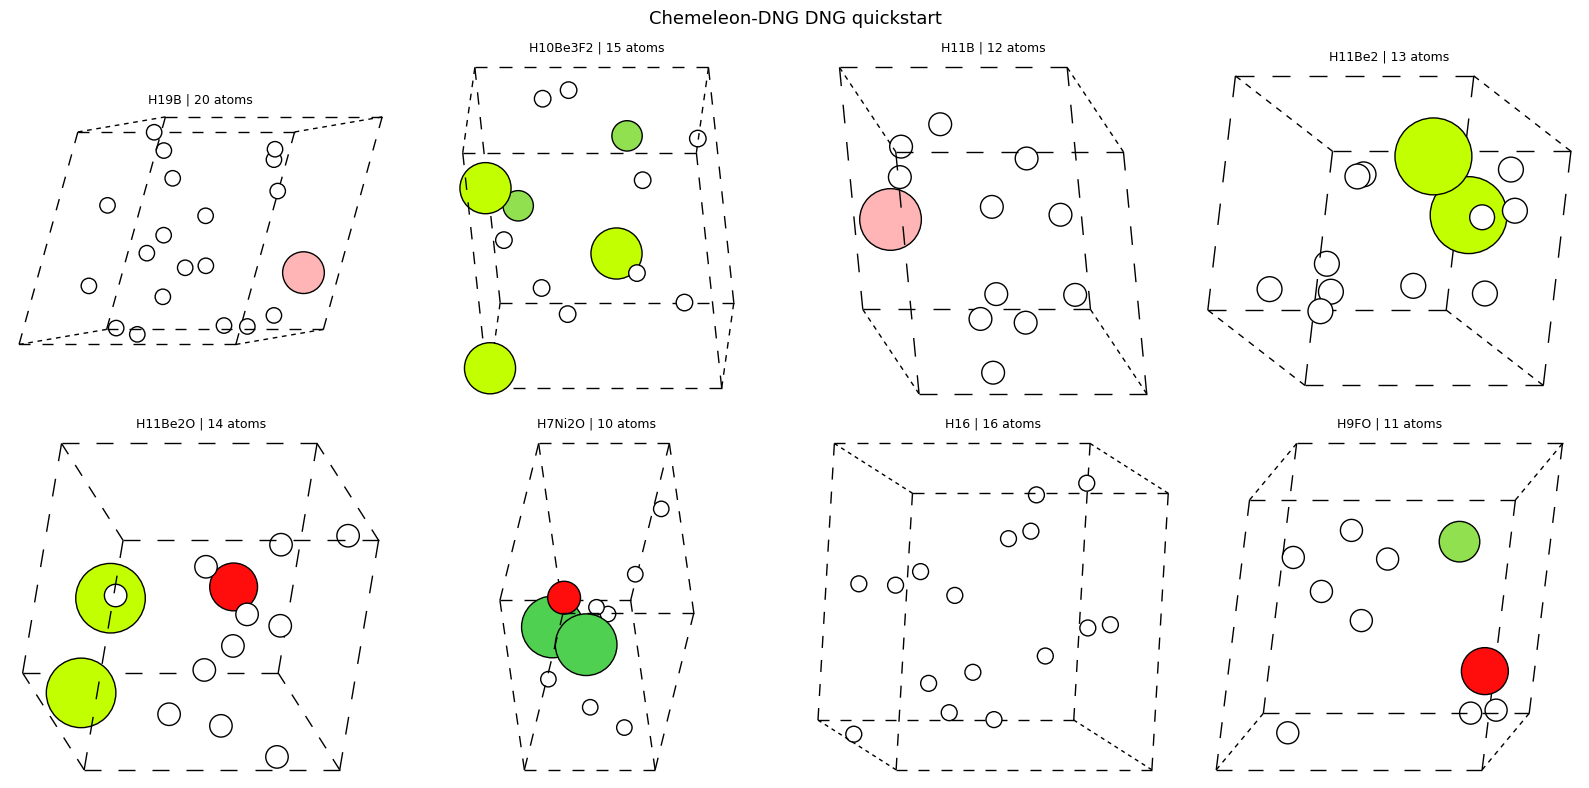

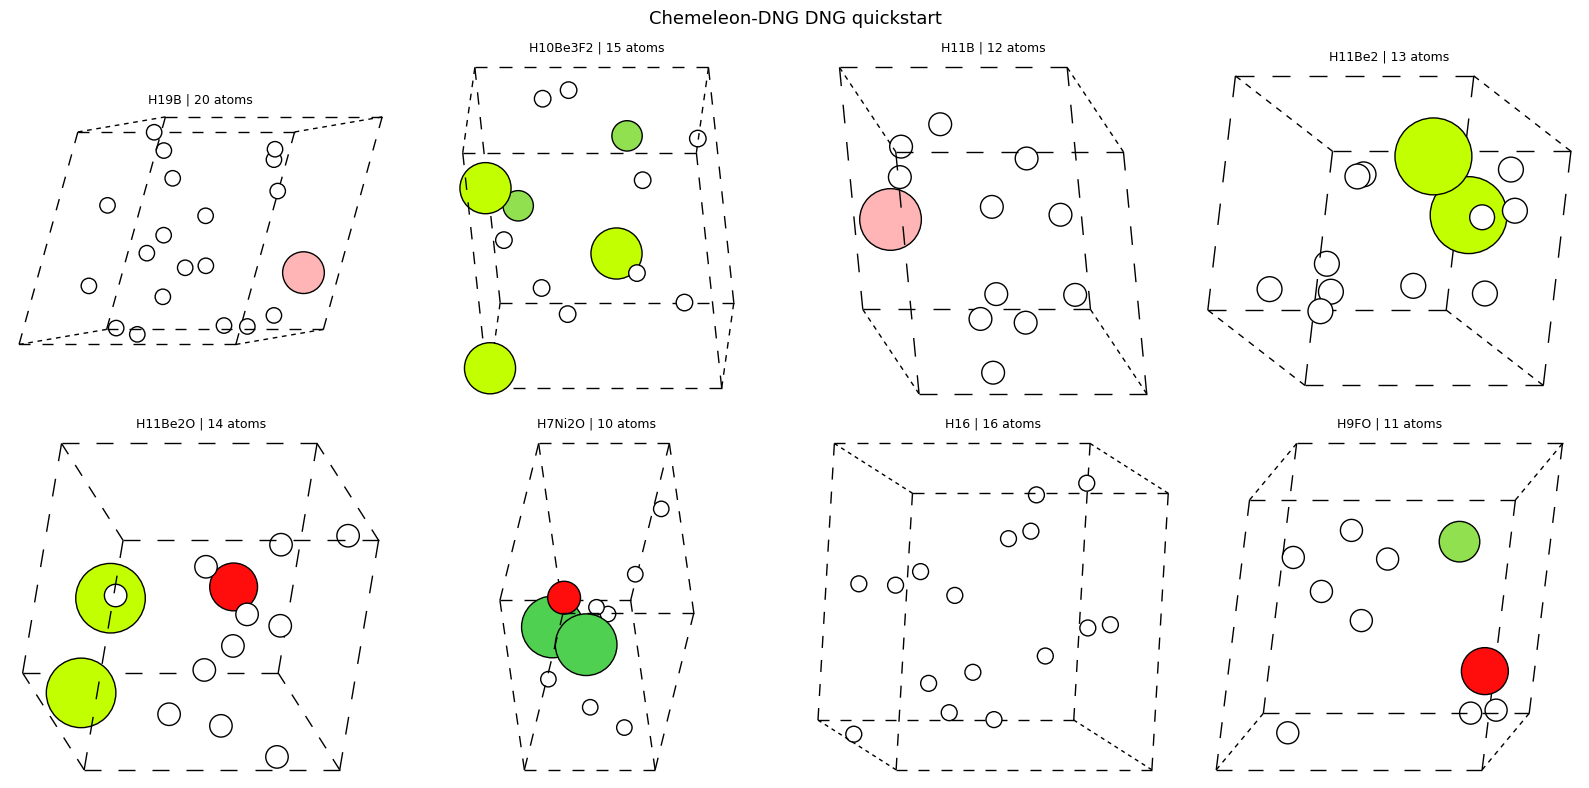

In [12]:
from ase.io import read

# The first DNG call downloads the pretrained checkpoints into chemeleon_dng_repo/ckpts if needed.
# We keep this to a single batch so the quickstart stays notebook-friendly on CPU while still
# giving us enough structures for a small gallery.
dng_output_dir = CHEMELEON_DNG_OUT / 'dng_quickstart'
dng_cif_paths = sample_chemeleon_dng(
    task='dng',
    num_samples=8,
    batch_size=8,
    output_dir=dng_output_dir,
    device=CHEMELEON_DNG_DEVICE,
    num_atom_distribution='mp-20',
)
dng_atoms_list = [read(path) for path in dng_cif_paths]

print('Generated:', len(dng_atoms_list), 'structures')
for i, atoms in enumerate(dng_atoms_list):
    print(i, atoms.get_chemical_formula(), len(atoms), f'{atoms.get_volume():.2f}')

show_atoms_gallery(
    dng_atoms_list,
    'Chemeleon-DNG DNG quickstart',
    CHEMELEON_DNG_OUT / 'dng_quickstart_gallery.png',
)


## 4) DNG steering and output analysis

Now we go beyond the default DNG call and use one of the real control knobs that Chemeleon-DNG exposes: the atom-count distribution.

We compare three DNG settings:

- the default `mp-20` atom-count prior,
- a **small-cell** schedule,
- a **large-cell** schedule.

This is not property conditioning in the MatterGen sense, but it *is* a genuine sampling control. It is useful whenever you want to bias the search toward smaller or larger unit cells before doing any downstream screening.

### What to notice

- The atom-count schedule should move the `n_sites` distribution directly.
- That in turn often changes volume and density distributions.
- This is a good example of a practical generative control that is easy to explain and easy to verify.
- Just like in the MatterGen section, we can rank the low-density and high-density tails after generation to decide what to inspect next.

> **Quick check:** what is the model control you are actually changing in this DNG steering study?
>
><details><summary>Answer</summary>
>
>You are changing the distribution of the requested number of atoms per generated cell. That is a direct sampling control, and it should show up most clearly in the `n_sites` and volume statistics.
>
></details>


In [ ]:
import matplotlib.pyplot as plt
from html import escape
from IPython.display import HTML, display

# Add two explicit atom-count schedules so we can compare the default mp-20 prior
# with smaller-cell and larger-cell steering.
dng_small_output_dir = CHEMELEON_DNG_OUT / 'dng_small_cells'
dng_large_output_dir = CHEMELEON_DNG_OUT / 'dng_large_cells'

try:
    render_rank_table
except NameError:
    def render_rank_table(title, rows, headers):
        th_style = 'border:1px solid #ddd; padding:4px 8px; text-align:left; background:#eff6ff;'
        td_style = 'border:1px solid #ddd; padding:4px 8px; text-align:left;'

        def fmt(value):
            if isinstance(value, float):
                return f'{value:.3f}'
            return str(value)

        body = []
        for row in rows:
            body.append(
                '<tr>'
                + ''.join(f'<td style="{td_style}">{escape(fmt(row[h]))}</td>' for h in headers)
                + '</tr>'
            )
        html = f'''<div style="margin:0.5rem 0 0.25rem 0; font-weight:600;">{escape(title)}</div>
        <table style="border-collapse:collapse; min-width:760px; margin:0.35rem 0 1rem 0;">
          <thead><tr>{''.join(f'<th style="{th_style}">{escape(h)}</th>' for h in headers)}</tr></thead>
          <tbody>{''.join(body)}</tbody>
        </table>'''
        display(HTML(html))

dng_small_cif_paths = sample_chemeleon_dng(
    task='dng',
    num_samples=3,
    batch_size=3,
    output_dir=dng_small_output_dir,
    device=CHEMELEON_DNG_DEVICE,
    num_atom_distribution=[6, 6, 7],
)
dng_large_cif_paths = sample_chemeleon_dng(
    task='dng',
    num_samples=3,
    batch_size=3,
    output_dir=dng_large_output_dir,
    device=CHEMELEON_DNG_DEVICE,
    num_atom_distribution=[14, 14, 16],
)

dng_run_atoms = {
    'mp20_prior': dng_atoms_list,
    'small_cells': [read(path) for path in dng_small_cif_paths],
    'large_cells': [read(path) for path in dng_large_cif_paths],
}
dng_run_titles = {
    'mp20_prior': 'Default mp-20 prior',
    'small_cells': 'Small-cell schedule',
    'large_cells': 'Large-cell schedule',
}
dng_colors = {
    'mp20_prior': '#7aa2f7',
    'small_cells': '#9ece6a',
    'large_cells': '#f7768e',
}

dng_rows = []
for label, atoms_list in dng_run_atoms.items():
    for i, atoms in enumerate(atoms_list):
        volume = float(atoms.get_volume())
        dng_rows.append({
            'label': label,
            'display_name': dng_run_titles[label],
            'sample_id': i,
            'formula': atoms.get_chemical_formula(),
            'n_sites': len(atoms),
            'volume': volume,
            'density': float(atoms.get_masses().sum() / max(volume, 1e-12)),
        })

print(f'Loaded {len(dng_rows)} DNG structures across {len(dng_run_atoms)} steering settings')
for label, atoms_list in dng_run_atoms.items():
    rows = [row for row in dng_rows if row['label'] == label]
    print(
        f"- {dng_run_titles[label]}: mean n_sites={np.mean([row['n_sites'] for row in rows]):.2f}, "
        f"mean density={np.mean([row['density'] for row in rows]):.3f}, "
        f"unique formulas={len({row['formula'] for row in rows})}"
    )

fig, axes = plt.subplots(2, 3, figsize=(16, 10), facecolor='white')
for x, label in enumerate(dng_run_atoms, start=1):
    rows = [row for row in dng_rows if row['label'] == label]
    jitter = np.linspace(-0.08, 0.08, num=len(rows)) if len(rows) > 1 else np.array([0.0])
    axes[0, 0].scatter(np.full(len(rows), x) + jitter, [row['n_sites'] for row in rows], s=65, color=dng_colors[label], edgecolors='black', linewidths=0.3)
    axes[0, 1].scatter(np.full(len(rows), x) + jitter, [row['density'] for row in rows], s=65, color=dng_colors[label], edgecolors='black', linewidths=0.3)
    axes[1, 2].bar(x, len({row['formula'] for row in rows}), color=dng_colors[label], width=0.6)
    axes[1, 0].scatter([row['volume'] for row in rows], [row['density'] for row in rows], s=95, color=dng_colors[label], label=dng_run_titles[label], edgecolors='black', linewidths=0.3)
    axes[0, 2].hist([row['density'] for row in rows], bins=4, alpha=0.55, color=dng_colors[label], label=dng_run_titles[label])
    axes[1, 1].hist([row['n_sites'] for row in rows], bins=np.arange(5.5, 17.6, 1.0), alpha=0.5, color=dng_colors[label], label=dng_run_titles[label])

for ax, ylabel, title in [
    (axes[0, 0], 'n_sites', 'Atom-count control in DNG'),
    (axes[0, 1], 'density', 'Density by DNG steering setting'),
]:
    ax.set_xticks(range(1, len(dng_run_atoms) + 1))
    ax.set_xticklabels([dng_run_titles[label] for label in dng_run_atoms], rotation=15, ha='right')
    ax.set_ylabel(ylabel)
    ax.set_title(title)

axes[0, 2].set_title('Density distributions across DNG steering settings')
axes[0, 2].set_xlabel('density')
axes[0, 2].set_ylabel('count')
axes[0, 2].legend(frameon=False)

axes[1, 0].set_title('Density vs volume across DNG steering settings')
axes[1, 0].set_xlabel('volume')
axes[1, 0].set_ylabel('density')
axes[1, 0].legend(frameon=False)

axes[1, 1].set_title('Atom-count distributions across DNG steering settings')
axes[1, 1].set_xlabel('n_sites')
axes[1, 1].set_ylabel('count')
axes[1, 1].legend(frameon=False)

axes[1, 2].set_xticks(range(1, len(dng_run_atoms) + 1))
axes[1, 2].set_xticklabels([dng_run_titles[label] for label in dng_run_atoms], rotation=15, ha='right')
axes[1, 2].set_ylabel('unique formulas')
axes[1, 2].set_title('Formula diversity per DNG steering setting')

plt.tight_layout()
plt.show()

dng_sorted_by_density = sorted(dng_rows, key=lambda row: row['density'])
render_rank_table(
    'Lowest-density DNG candidates across all steering settings',
    dng_sorted_by_density[:3],
    ['display_name', 'formula', 'n_sites', 'volume', 'density'],
)
render_rank_table(
    'Highest-density DNG candidates across all steering settings',
    list(reversed(dng_sorted_by_density[-3:])),
    ['display_name', 'formula', 'n_sites', 'volume', 'density'],
)

show_atoms_gallery(
    dng_run_atoms['small_cells'][:3],
    'Chemeleon-DNG small-cell DNG steering',
    CHEMELEON_DNG_OUT / 'dng_small_cells_gallery.png',
    subtitles=[
        f"{atoms.get_chemical_formula()} | {len(atoms)} atoms | density={float(atoms.get_masses().sum() / max(atoms.get_volume(), 1e-12)):.3f}"
        for atoms in dng_run_atoms['small_cells'][:3]
    ],
    columns=3,
)
show_atoms_gallery(
    dng_run_atoms['large_cells'][:3],
    'Chemeleon-DNG large-cell DNG steering',
    CHEMELEON_DNG_OUT / 'dng_large_cells_gallery.png',
    subtitles=[
        f"{atoms.get_chemical_formula()} | {len(atoms)} atoms | density={float(atoms.get_masses().sum() / max(atoms.get_volume(), 1e-12)):.3f}"
        for atoms in dng_run_atoms['large_cells'][:3]
    ],
    columns=3,
)
show_atoms_gallery(
    [dng_run_atoms[row['label']][row['sample_id']] for row in dng_sorted_by_density[:3]],
    'Lowest-density DNG candidates across all steering settings',
    CHEMELEON_DNG_OUT / 'dng_low_density_gallery.png',
    subtitles=[
        f"{row['display_name']} | {row['formula']} | density={row['density']:.3f}"
        for row in dng_sorted_by_density[:3]
    ],
    columns=3,
)
show_atoms_gallery(
    [dng_run_atoms[row['label']][row['sample_id']] for row in list(reversed(dng_sorted_by_density[-3:]))],
    'Highest-density DNG candidates across all steering settings',
    CHEMELEON_DNG_OUT / 'dng_high_density_gallery.png',
    subtitles=[
        f"{row['display_name']} | {row['formula']} | density={row['density']:.3f}"
        for row in list(reversed(dng_sorted_by_density[-3:]))
    ],
    columns=3,
)


## 5) CSP quickstart: formula-conditioned generation

Now we switch from open-ended DNG to the explicitly conditioned Chemeleon-DNG task.

Here the condition is a target **formula**, so the chemistry is fixed and the model only has to infer plausible crystal structures for that composition.

### What to notice

- This is the cleanest Chemeleon-DNG example of conditional generation.
- Unlike MatterGen's scalar target, a formula condition is easy to verify directly from the output stoichiometry.
- The natural application is formula screening: pick one or two candidate chemistries, generate several structures for each, then rank them with cheap diagnostics before doing more expensive physics.
- We keep two formulas here so the notebook can show a real conditional comparison rather than a one-off gallery.

> **Quick check:** why is CSP a stronger demonstration of conditioning than a single DNG run?
>
><details><summary>Answer</summary>
>
>Because the condition is explicit and verifiable. You can directly check whether the generated structures respect the requested composition and whether different formulas occupy different structural regimes.
>
></details>


In [ ]:
from ase.io import read

# CSP is the explicitly conditioned Chemeleon-DNG workflow.
# We keep multiple samples per formula, but fit them into one batch so the notebook stays lighter.
csp_targets = ['NaCl', 'LiMnO2']
CSP_SAMPLES_PER_FORMULA = 2
csp_samples = {}
for formula in csp_targets:
    out_dir = CHEMELEON_DNG_OUT / f'csp_{formula.lower()}'
    cif_paths = sample_chemeleon_dng(
        task='csp',
        formulas=[formula],
        num_samples=CSP_SAMPLES_PER_FORMULA,
        batch_size=2,
        output_dir=out_dir,
        device=CHEMELEON_DNG_DEVICE,
    )
    atoms_list = [read(path) for path in cif_paths]
    csp_samples[formula] = atoms_list
    print(f'{formula}: {len(atoms_list)} structures')
    show_atoms_gallery(
        atoms_list,
        f'Chemeleon-DNG CSP: {formula}',
        CHEMELEON_DNG_OUT / f'csp_{formula.lower()}_gallery.png',
        subtitles=[
            f"{atoms.get_chemical_formula()} | {len(atoms)} atoms | volume={atoms.get_volume():.1f} Å³"
            for atoms in atoms_list
        ],
    )


## 6) CSP distributions, galleries, and screening

Once we have multiple CSP samples per formula, the notebook can do more than show one gallery. We can compare how the target chemistry changes density, volume, and atom-count distributions, then rank the outputs as a tiny formula-conditioned discovery workflow.

### What to notice

- Formula conditioning should separate the outputs into different structural regions.
- The same cheap screening ideas from the MatterGen section still apply here.
- Ranking the densest or lightest candidates is not a claim about thermodynamic stability; it is a practical way to decide which generated structures to inspect next.
- The formula-match table is useful because it separates “did the generator respect the chemistry?” from “which respected structures look most interesting?”

> **Quick check:** what is the conceptual difference between *conditioning* and *screening* in this CSP workflow?
>
><details><summary>Answer</summary>
>
>Conditioning tells the generator what chemistry to realize. Screening happens afterward, when you compute simple statistics such as density or volume to decide which generated candidates deserve closer study.
>
></details>


In [ ]:
import matplotlib.pyplot as plt
from ase.formula import Formula

# Compare the CSP outputs across target formulas and rank them with the same lightweight
# density screen we used for MatterGen.
csp_rows = []
for formula, atoms_list in csp_samples.items():
    target_reduced = Formula(formula).reduce()[0].format('hill')
    for i, atoms in enumerate(atoms_list):
        volume = float(atoms.get_volume())
        generated_reduced = Formula(atoms.get_chemical_formula()).reduce()[0].format('hill')
        csp_rows.append({
            'formula_target': formula,
            'sample_id': i,
            'generated_formula': atoms.get_chemical_formula(),
            'generated_reduced_formula': generated_reduced,
            'formula_match': generated_reduced == target_reduced,
            'n_sites': len(atoms),
            'volume': volume,
            'density': float(atoms.get_masses().sum() / max(volume, 1e-12)),
            'atoms': atoms,
        })

print(f'Loaded {len(csp_rows)} CSP structures across {len(csp_samples)} formulas')
for formula in csp_targets:
    subset = [row for row in csp_rows if row['formula_target'] == formula]
    print(
        f"- {formula}: mean density={np.mean([row['density'] for row in subset]):.3f}, "
        f"mean volume={np.mean([row['volume'] for row in subset]):.2f}, "
        f"formula-match fraction={np.mean([row['formula_match'] for row in subset]):.2f}"
    )

colors = {'NaCl': '#7aa2f7', 'LiMnO2': '#f7768e'}
fig, axes = plt.subplots(2, 3, figsize=(15, 9), facecolor='white')
for x, formula in enumerate(csp_targets, start=1):
    subset = [row for row in csp_rows if row['formula_target'] == formula]
    jitter = np.linspace(-0.06, 0.06, num=len(subset)) if len(subset) > 1 else np.array([0.0])
    axes[0, 0].scatter(np.full(len(subset), x) + jitter, [row['density'] for row in subset], s=65, color=colors[formula], edgecolors='black', linewidths=0.3)
    axes[0, 1].scatter(np.full(len(subset), x) + jitter, [row['volume'] for row in subset], s=65, color=colors[formula], edgecolors='black', linewidths=0.3)
    axes[1, 0].scatter([row['volume'] for row in subset], [row['density'] for row in subset], label=formula, s=90, color=colors[formula], edgecolors='black', linewidths=0.3)
    axes[1, 1].bar(x, np.mean([row['formula_match'] for row in subset]), color=colors[formula], width=0.6)
    axes[0, 2].hist([row['density'] for row in subset], bins=4, alpha=0.55, color=colors[formula], label=formula)
    axes[1, 2].scatter(np.full(len(subset), x) + jitter, [row['n_sites'] for row in subset], s=65, color=colors[formula], edgecolors='black', linewidths=0.3)

for ax, ylabel, title in [
    (axes[0, 0], 'density', 'Density by CSP target formula'),
    (axes[0, 1], 'volume', 'Volume by CSP target formula'),
    (axes[1, 2], 'n_sites', 'Atom count by CSP target formula'),
]:
    ax.set_xticks(range(1, len(csp_targets) + 1))
    ax.set_xticklabels(csp_targets)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

axes[0, 2].set_title('Density distributions across CSP target formulas')
axes[0, 2].set_xlabel('density')
axes[0, 2].set_ylabel('count')
axes[0, 2].legend(frameon=False)

axes[1, 0].set_title('CSP density vs volume')
axes[1, 0].set_xlabel('volume')
axes[1, 0].set_ylabel('density')
axes[1, 0].legend(frameon=False)

axes[1, 1].set_xticks(range(1, len(csp_targets) + 1))
axes[1, 1].set_xticklabels(csp_targets)
axes[1, 1].set_ylim(0, 1.05)
axes[1, 1].set_ylabel('formula-match fraction')
axes[1, 1].set_title('Did the generated stoichiometry match the target?')

plt.tight_layout()
plt.show()

csp_sorted_by_density = sorted(csp_rows, key=lambda row: row['density'])
render_rank_table(
    'Lowest-density CSP candidates across both target formulas',
    csp_sorted_by_density[:4],
    ['formula_target', 'generated_formula', 'formula_match', 'n_sites', 'volume', 'density'],
)
render_rank_table(
    'Highest-density CSP candidates across both target formulas',
    list(reversed(csp_sorted_by_density[-4:])),
    ['formula_target', 'generated_formula', 'formula_match', 'n_sites', 'volume', 'density'],
)

perfect_matches = [row for row in csp_rows if row['formula_match']]
if perfect_matches:
    perfect_matches = sorted(perfect_matches, key=lambda row: row['density'], reverse=True)
    render_rank_table(
        'Densest formula-matching CSP candidates',
        perfect_matches[:4],
        ['formula_target', 'generated_formula', 'n_sites', 'volume', 'density'],
    )

show_atoms_gallery(
    [row['atoms'] for row in csp_sorted_by_density[:2]],
    'Lowest-density CSP candidates across both target formulas',
    CHEMELEON_DNG_OUT / 'csp_low_density_gallery.png',
    subtitles=[
        f"{row['formula_target']} target | {row['generated_formula']} | density={row['density']:.3f}"
        for row in csp_sorted_by_density[:2]
    ],
    columns=2,
)
show_atoms_gallery(
    [row['atoms'] for row in list(reversed(csp_sorted_by_density[-2:]))],
    'Highest-density CSP candidates across both target formulas',
    CHEMELEON_DNG_OUT / 'csp_high_density_gallery.png',
    subtitles=[
        f"{row['formula_target']} target | {row['generated_formula']} | density={row['density']:.3f}"
        for row in list(reversed(csp_sorted_by_density[-2:]))
    ],
    columns=2,
)


## 7) Comparison lens: MatterGen vs Chemeleon-DNG

The comparison lens is simpler once both toolkits are on the page:

- MatterGen is the closer match to the direct crystal-diffusion baseline, and the notebook demonstrates that with an unconditional run plus a low-vs-high conditioned sweep.
- Chemeleon-DNG keeps a similar backbone but turns the user-facing workflow into two task modes, plus a useful DNG control knob through the atom-count schedule.
- Both halves of the notebook end the same way: with a candidate pool, summary tables, density / volume screens, and small structure galleries.
- If you can explain the table below, you can explain the difference between scalar-property steering, formula-conditioned generation, and post-generation screening in crystal diffusion workflows.

### Decision table

| If your goal is... | Prefer | Why |
| --- | --- | --- |
| learn the cleanest continuation of direct crystal diffusion | MatterGen | the workflow is closest to a base crystal prior plus optional guidance |
| steer generation with a scalar electronic or structural target | MatterGen | the notebook demonstrates scalar conditioning and guidance directly |
| generate candidates for a fixed formula and verify the condition immediately | Chemeleon-DNG CSP | the formula is explicit and easy to check from the output stoichiometry |
| do open-ended crystal generation while changing the cell-size search regime | Chemeleon-DNG DNG | the atom-count schedule is a simple and visible steering knob |
| compare candidate pools with the same cheap diagnostics | either | both halves end in density / volume / atom-count screening and galleries |
| choose one toolkit for a first practical diffusion-for-crystals workflow | MatterGen | it is the more direct bridge from the scratch crystal notebook |


## 8) Exercises

1. **DNG vs CSP:** In your own words, what is the difference between DNG and CSP?

<details><summary>Answer</summary>

DNG generates structures from scratch, while CSP generates structures conditioned on a target formula.

</details>

2. **Band gap vs formula conditioning:** How does MatterGen's low-vs-high band-gap sweep differ from Chemeleon-DNG's CSP sweep?

<details><summary>Answer</summary>

MatterGen changes a scalar target while leaving the chemistry open, whereas CSP fixes the chemistry directly and asks the model to generate plausible structures for that formula.

</details>

3. **Why density still matters:** Why did this notebook keep plotting density even when density was not always the conditioned target?

<details><summary>Answer</summary>

Because density is a cheap structural diagnostic and a useful screening statistic. It helps show whether different conditions move the generated structures into different structural regimes.

</details>

4. **Pick the right tool:** When would you choose Chemeleon-DNG over MatterGen?

<details><summary>Answer</summary>

Chemeleon-DNG is a good choice when you want a compact DNG/CSP workflow, especially if your main question is composition-conditioned structure generation.

</details>

5. **Screening workflow:** Suppose you wanted to prioritize compact, high-density candidates from either model. What would the next step be after generation?

<details><summary>Answer</summary>

Collect the generated structures, compute a screening statistic such as density or volume, rank the candidates, and then pass the most interesting ones to a more expensive downstream workflow such as relaxation or DFT.

</details>


## 9) Troubleshooting

- If `chemeleon_dng_repo/` exists but has no `pyproject.toml`, rerun the setup cell. The setup checks for incomplete clones, moves them aside, and reclones the repo cleanly.
- The Python environment lives in `tempfile.gettempdir()/chemeleon-dng-venv` rather than inside the repo. That avoids incomplete `torch` and `numpy` installs on mounted filesystems such as OneDrive and some WSL/Colab paths.
- The notebook anchors itself to the repo root, so outputs land inside `diffusion-model-tutorial/` rather than the parent directory.
- The first DNG or CSP run downloads about $523\,\mathrm{MB}$ of checkpoints into `chemeleon_dng_repo/ckpts/`. If that download is interrupted, rerun the first sampling cell.
- The Chemeleon subprocess forces `MPLBACKEND='Agg'` and uses a writable temporary Matplotlib cache, so it does not inherit Jupyter's inline backend and fail during import.
- The sampling helper reuses existing CIFs by default when the output directory already contains the expected number of structures. If you want a fully fresh run, delete the relevant output directory first.
- `CHEMELEON_DNG_DEMO_TIMESTEPS` controls the notebook-speed reverse process. Increase it if you want higher-fidelity samples and can tolerate longer runtimes.
- Keep `CHEMELEON_DNG_DEVICE = 'cpu'` while you are validating the workflow. Once the notebook is stable on your machine, switch it to `'cuda'` for faster sampling.

## 10) Next steps

- In MatterGen, try a second conditioned checkpoint such as `chemical_system` or `space_group` and repeat the same sweep-plus-screening workflow.
- In Chemeleon-DNG, expand the CSP formula list and compare how the density-volume clouds move as the chemistry changes.
- Increase the DNG atom-count schedules from the tiny tutorial values here to broader small-cell and large-cell sweeps once you move to GPU.
- Take the screened high-density and low-density candidates from either model and pass them to a relaxation or stability-analysis workflow.
- Build one shared post-processing script that ingests MatterGen and Chemeleon outputs together, then ranks candidates by the same screening criteria.
